# Introdução Às Redes Neurais 

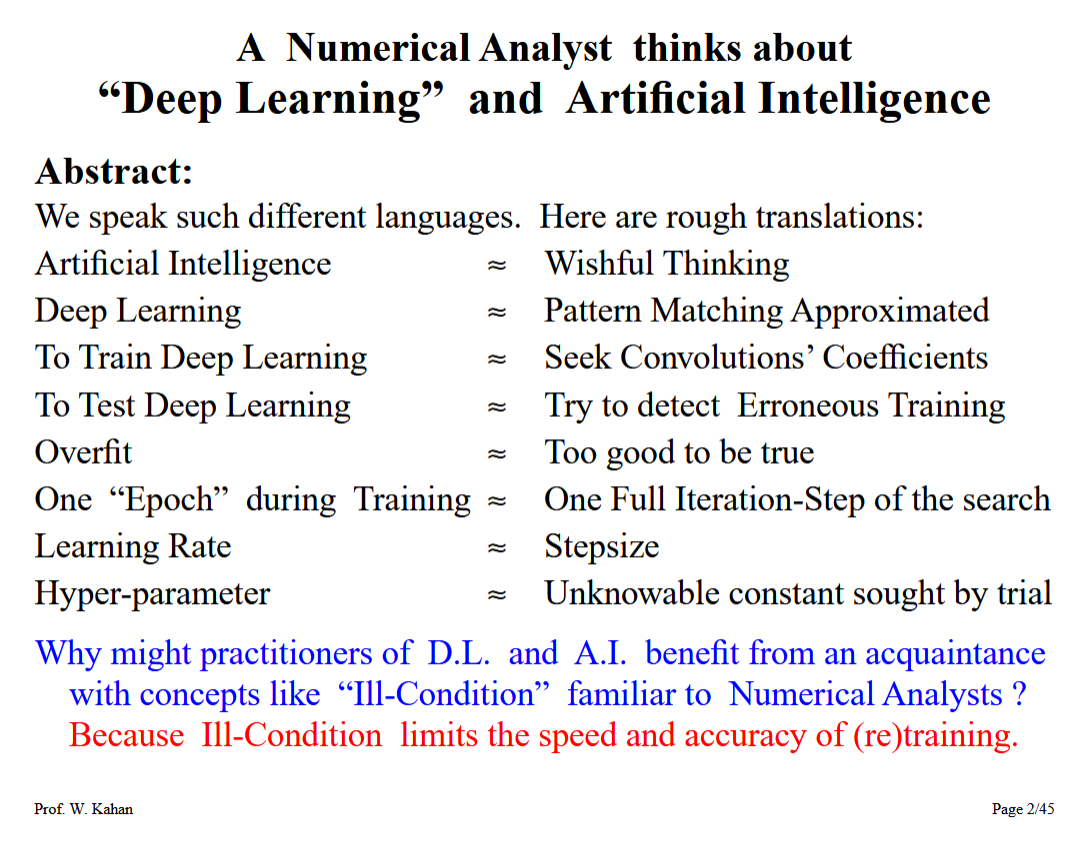


# Aula Introdutória - Artigo: Perceptrons: The First Neural Network

In [ ]:
%%HTML
<a href="https://medium.com/data-science/perceptrons-the-first-neural-network-model-8b3ee4513757">Perceptrons: The First Neural Network Model</a>

### Rede Neural Multicamadas com Retropropagação





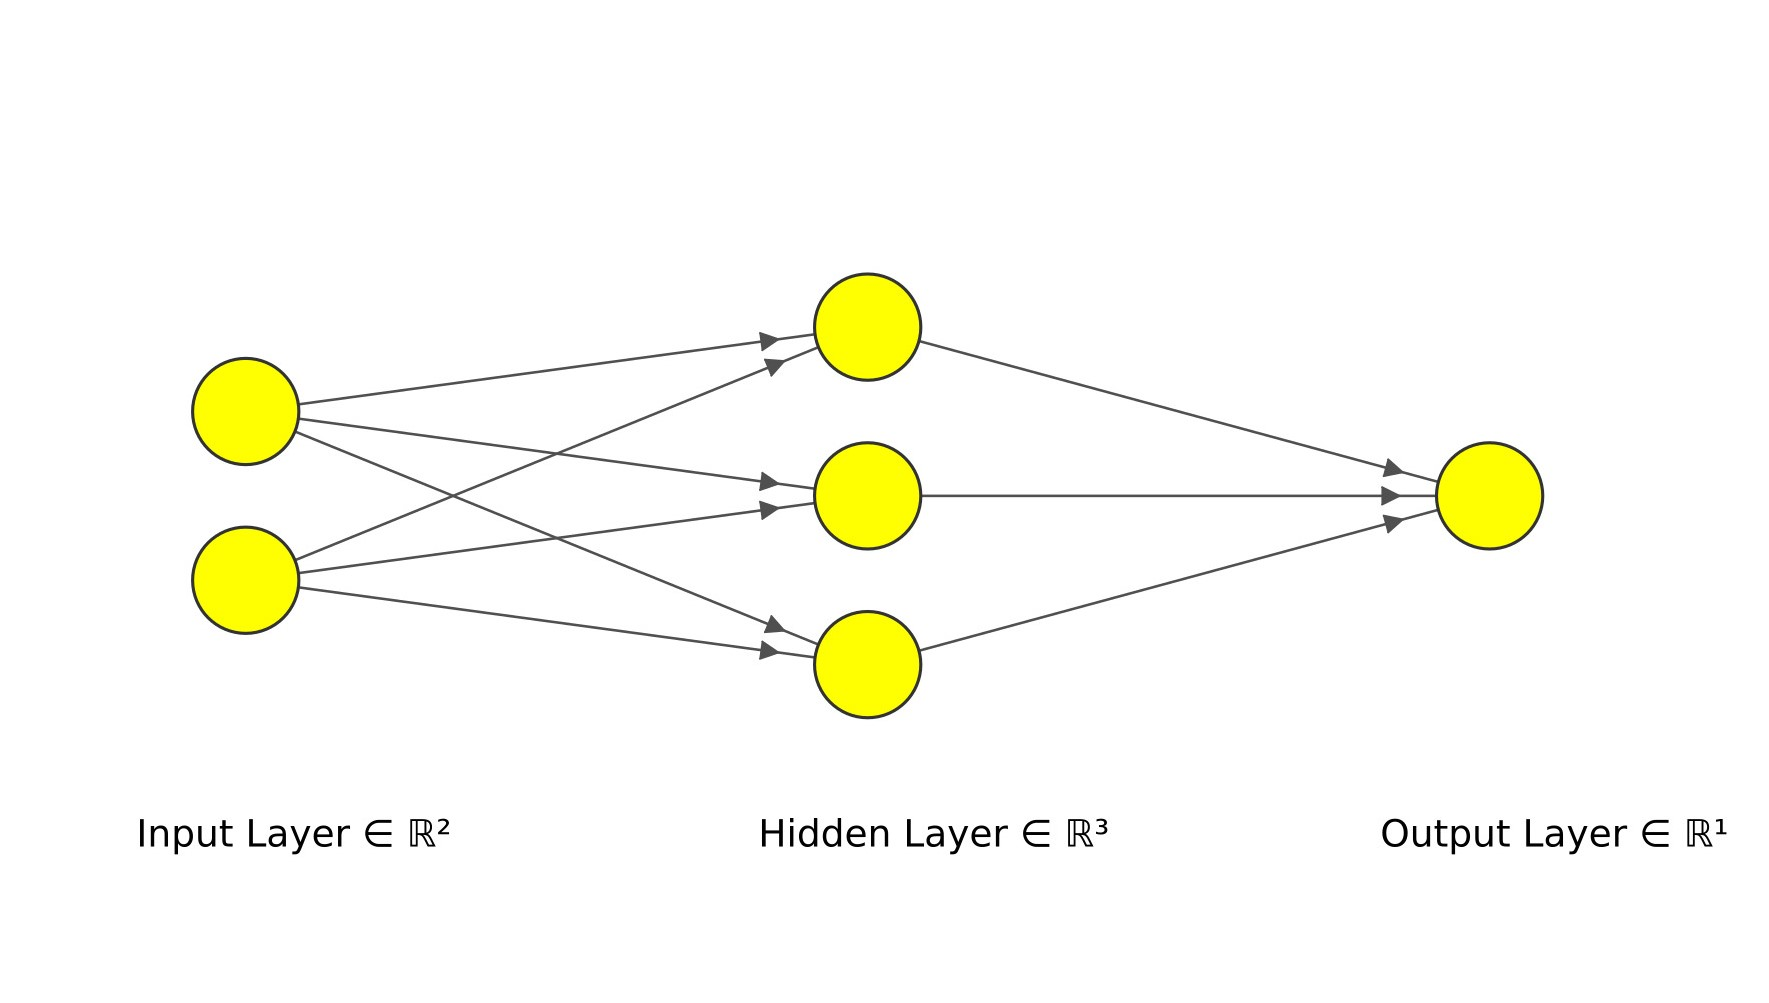

In [ ]:
import numpy as np

def activation_function(x):
 # return np.heaviside(x, 1)
 return 1 / (1 + np.exp(-x))



def deriv_activ_function(x):
  fx = activation_function(x)
  return fx * (1 - fx)

def mse_loss(y_true, y_pred):
  return ((y_true - y_pred) ** 2).mean()

class NeuralNetwork:
  
  def __init__(self):
    # Weights
    self.w1 = np.random.normal()
    self.w2 = np.random.normal()
    self.w3 = np.random.normal()
    self.w4 = np.random.normal()
    self.w5 = np.random.normal()
    self.w6 = np.random.normal()   
    self.w7 = np.random.normal()
    self.w8 = np.random.normal()
    self.w9 = np.random.normal()

    # Biases
    self.b1 = np.random.normal()
    self.b2 = np.random.normal()
    self.b3 = np.random.normal()
    self.b4 = np.random.normal()

  def feedforward(self, x):

    h1 = activation_function(self.w1 * x[0] + self.w2 * x[1] + self.b1)
    h2 = activation_function(self.w3 * x[0] + self.w4 * x[1] + self.b2)
    h3 = activation_function(self.w5 * x[0] + self.w6 * x[1] + self.b3)
    o1 = activation_function(self.w7 * h1 + self.w8 * h2 + self.w9*h3+self.b4)
    return o1

  def train(self, data, y_trues,loss):
    
    alpha = 0.1
    epochs = 2000 # number of times to loop through the entire dataset
    iloss=0

    for epoch in range(epochs):
      for x, y_true in zip(data, y_trues):
        # Feedforward 
        sum_h1 = self.w1 * x[0] + self.w2 * x[1] + self.b1
        h1 = activation_function(sum_h1)

        sum_h2 = self.w3 * x[0] + self.w4 * x[1] + self.b2
        h2 = activation_function(sum_h2)

        sum_h3 = self.w5 * x[0] + self.w6 * x[1] + self.b3
        h3 = activation_function(sum_h3)

        sum_o1 = self.w7 * h1 + self.w8 * h2 + self.w9*h3 + self.b4
        o1 = activation_function(sum_o1)
        y_pred = o1

        # --- Calculate partial derivatives.
        d_L_d_ypred = -2 * (y_true - y_pred)

        # Neuron o1
        d_ypred_d_w7 = h1 * deriv_activ_function(sum_o1)
        d_ypred_d_w8 = h2 * deriv_activ_function(sum_o1)
        d_ypred_d_w9 = h3 * deriv_activ_function(sum_o1)
        d_ypred_d_b4 = deriv_activ_function(sum_o1)

        d_ypred_d_h1 = self.w7 * deriv_activ_function(sum_o1)
        d_ypred_d_h2 = self.w8 * deriv_activ_function(sum_o1)
        d_ypred_d_h3 = self.w9 * deriv_activ_function(sum_o1)

        # Neuron h1
        d_h1_d_w1 = x[0] * deriv_activ_function(sum_h1)
        d_h1_d_w2 = x[1] * deriv_activ_function(sum_h1)
        d_h1_d_b1 = deriv_activ_function(sum_h1)

        # Neuron h2
        d_h2_d_w3 = x[0] * deriv_activ_function(sum_h2)
        d_h2_d_w4 = x[1] * deriv_activ_function(sum_h2)
        d_h2_d_b2 = deriv_activ_function(sum_h2)

        # Neuron h3
        d_h3_d_w5 = x[0] * deriv_activ_function(sum_h3)
        d_h3_d_w6 = x[1] * deriv_activ_function(sum_h3)
        d_h3_d_b3 = deriv_activ_function(sum_h3)

        # --- Update weights and biases
        # Neuron h1
        self.w1 -= alpha * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_w1
        self.w2 -= alpha * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_w2
        self.b1 -= alpha * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_b1

        # Neuron h2
        self.w3 -= alpha * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_w3
        self.w4 -= alpha * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_w4
        self.b2 -= alpha * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_b2

        # Neuron h3
        self.w5 -= alpha * d_L_d_ypred * d_ypred_d_h3 * d_h3_d_w5
        self.w6 -= alpha * d_L_d_ypred * d_ypred_d_h3 * d_h3_d_w6
        self.b3 -= alpha * d_L_d_ypred * d_ypred_d_h3 * d_h3_d_b3

        # Neuron o1
        self.w7 -= alpha * d_L_d_ypred * d_ypred_d_w7
        self.w8 -= alpha * d_L_d_ypred * d_ypred_d_w8
        self.w9 -= alpha * d_L_d_ypred * d_ypred_d_w9
        self.b4 -= alpha * d_L_d_ypred * d_ypred_d_b4

      # --- Calculate total loss at the end of each epoch
      if epoch % 10 == 0:
        y_preds = np.apply_along_axis(self.feedforward, 1, data)
        print('y_preds=',np.round(y_preds))
        loss[iloss] = mse_loss(y_trues, y_preds)
        
        print("Epoch %d loss: %.3f" % (epoch, loss[iloss]))
        iloss=iloss+1
        
        

# Data
data = np.array([
  [0, 0], 
  [0,1],  
  [1,0],   
  [1,1], 
])
y_trues = np.array([
  0, 
  1, 
  1,
  0, 
])

# Train the NNetwork

loss=np.zeros(200)
network = NeuralNetwork()
network.train(data, y_trues,loss)
iep=np.arange(200)
import matplotlib.pyplot as plt
plt.title('Loss vs. Epochs')
plt.plot(iep,loss)
plt.xlabel('Epochs/10')
plt.ylabel('Loss')


Referências até aqui:

[1] Michael Collins, Convergence Proof for the Perceptron Algorithm

[2] https://www.geeksforgeeks.org/perceptron-convergence-theorem-in-neural-networks/

[3]Rumelhart, D., Hinton, G. & Williams, R. Learning representations by back-propagating errors. Nature 323, 533–536 (1986). https://doi.org/10.1038/323533a0


# Vetorização

Referências:

[1]  Dr. Andy Thomas  Neural Networks Tutorial – A Pathway to Deep Learning :
http://deeplearning.lipingyang.org/wp-content/uploads/2016/12/Neural-Networks-Tutorial-A-Pathway-to-Deep-Learning-Adventures-in-Machine-Learning.pdf

[2] https://victorzhou.com/blog/intro-to-rnns/#73-gradients

[3] Terence Parr and Jeremy Howard, The Matrix Calculus You Need For Deep Learning, arXiv, 2018.


Os dados de entrada devem ter o formato de matrizes $X[n_i,n_a]$
    e $y[n_o,n_a]$, onde $n_i$ é o número de dados de entrada em cada amostra, $n_a$ é o número de amostras e $n_o$ é o número de neurônios na camada de saída.
    
Assim, como exemplo, uma determinada rede com conexão densa possui $n_i$=2 dados de entrada e $n_a$=4. Considere ainda uma camada oculta com dois neurônios, e um único neurônio na camada de saída, havendo portanto uma saída para cada amostra. Portanto, temos as seguintes matrizes dimensionadas a seguir: $X[2,4],\, y[1,4],\, W^h[2,2],\, W^o[1,2],\, b^h[2,1],\, e\, b^o[1,1]$.
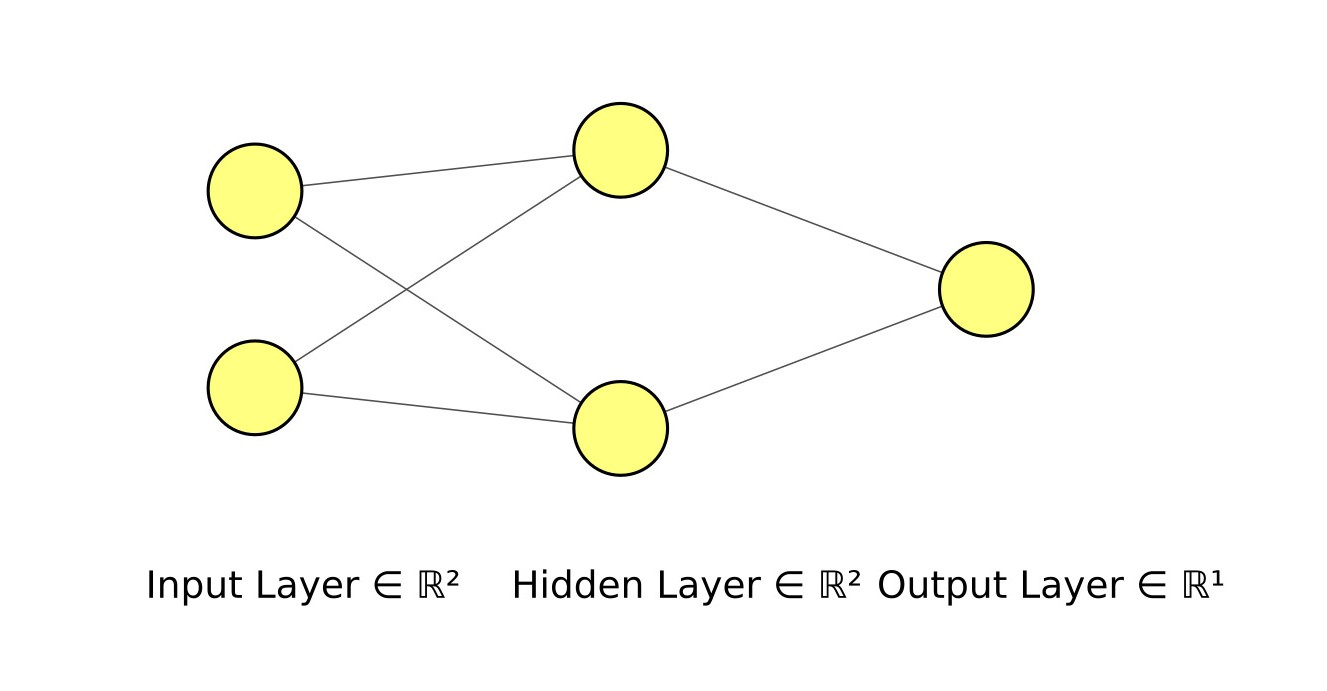

### Assim, na propagação direta (*feedforward*) podemos escrever para cada neurônio da camada intermediária,

$Z^h_{1}=W_{11}^hX_{11}+W_{12}^hX_{21}+b^h_{1}+W_{11}^hX_{12}+W_{12}^hX_{22}+b^h_{1}+ \textellipsis +W_{11}^hX_{14}+W_{12}^hX_{24}+b^h_{1}$

$Z^h_{2}=W_{21}^hX_{11}+ W_{21}X_{21}+b^h_{2}+W_{21}^hX_{12}+W_{22}^hX_{22}+b^h_{2}+ \textellipsis +W_{21}^hX_{14}+W_{22}^hX_{24}+b^h_{2}$. 

Colocando as duas equações em uma única equação matricial,

$Z_{[2,4]}^h=W_{[2,2]}^hX_{[2,4]}+b_{[2,1]}^h$. Na saída da camada escondida, podemos escrever que

$H_{[2,4]}=f_a(Z^h)$, onde $H=\begin{bmatrix}
h_1 \\
h_2
\end{bmatrix}=\begin{bmatrix}
f_a(Z^h_{1}) \\
f_a(Z^h_{2})
\end{bmatrix}$, e $h_1$ e $h_2$ tem dimensões [1,4]. Finalmente, para a camada de saída

$Z_{[1,4]}^o=\begin{bmatrix} W_{11}^o & W_{12}^o \end{bmatrix}\begin{bmatrix}
h_1 \\
h_2
\end{bmatrix}+\begin{bmatrix}
b_o \end{bmatrix}=W_{[1,2]}^oH_{[2,4]}+b_{[1,1]}^o$ e $ y_p=f_a(Z^o)$ com dimensões [1,4].

### Retropropagação (*backpropagation*)

na camada de saída partimos do *array* $\frac{\partial{L}}{\partial{Y_p}}$,

$\frac{\partial{L}}{\partial{Y_p}}_{[1,4]}=\begin{bmatrix} \frac{\partial{L}}{\partial{Y_{p1}}} & \frac{\partial{L}}{\partial{Y_{p2}}} & \frac{\partial{L}}{\partial{Y_{p3}}} & \frac{\partial{L}}{\partial{Y_{p4}}}\end{bmatrix},$

$\frac{\partial{L}}{\partial{W_{11}^o}}=\underbrace{\frac{\partial{L}}{\partial{Y_p}}\frac{\partial{y_p}}{\partial{Z^o}}}_{\frac{\partial{L}}{\partial{Z^o}}}\frac{\partial{Z^o}}{\partial{W_{11}^o}}=\frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)\frac{\partial(W_{11}^o h_1+W_{12}^o h_2)}{\partial{W_{11}^o}}=\frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)h_1$

$\frac{\partial{L}}{\partial{W_{12}^o}}=\frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)h_2$

e

$\left[\frac{\partial{L}}{\partial{W^o}}\right]_{[1,2]}=\left[ \frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)\right]_{[1,4]}\left[H\right]_{[4,2]}^T$. Note que o produto $\frac{\partial{L}}{\partial{Y_p}}f_a'(Z^o)$ é executado termo a termo sobre as duas matrizes de dimensão [1,4].

Para a camada escondida podemos escrever

$\left[\frac{\partial{L}}{\partial{Z^h}}\right ]_{[2,4]}=\underbrace{\left(\begin{bmatrix} W_{11}^o \\ W_{12}^o\end{bmatrix}_{[2,1]}\begin{bmatrix} \frac{\partial{L}}{\partial{Z_1^o}} & \frac{\partial{L}}{\partial{Z_2^o}}&\frac{\partial{L}}{\partial{Z_3^o}}&\frac{\partial{L}}{\partial{Z_4^o}}\end{bmatrix}_{[1,4]}\right)}_{\frac{\partial L}{\partial H}}*\underbrace{\left[ f_a'(Z^h)\right]_{[2,4]}}_{\frac{\partial H}{\partial Z^h}}$, onde o último produto de matrizes de dimensões  [2,4] também é executado termo a termo. 

Finalmente, 

$\left[ \frac{\partial{L}}{\partial{W^h}} \right]_{[2,2]}=\frac{\partial{L}}{\partial{Z^h}}X^T=\left[\frac{\partial{L}}{\partial{Z^h}}\right ]_{[2,4]}\begin{bmatrix} X_{11}&X_{21}\\ X_{12}&X_{22}\\ X_{13}&X_{23}\\ X_{14}&X_{24}\end{bmatrix}_{[4,2]}$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class NeuralNetwork:
    
    """ Os dados de entrada devem ter o formato de matrizes x[n_input,n_amostras]
    e y[n_output,n_amostras]"""
    
    def __init__(self,hidden_activation, output_activation,loss,
                 n_input, n_hidden, n_output):
        # Armazena o número de neurônios em cada camada
        self.n_input = n_input
        self.n_hidden = n_hidden
        self.n_output = n_output
        
        # Armazena as funções de ativação para cada camada e a função custo
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation
        self.loss=loss
        
        # Inicializa as matrizes de pesos
        np.random.seed(42)
        self.w_h=np.random.randn(n_hidden, n_input) * 0.01
        self.w_o=np.random.randn(n_output, n_hidden) * 0.01
        self.bias_h=np.zeros((n_hidden, 1))
        self.bias_o=np.zeros((n_output, 1))
        
        # Evolução da função custo
        self.loss_history=[]
   
    def activation_function(self,f_activ,x):
        if f_activ=='linear':
            return 1.*x
        if f_activ=='sigmoid':
            return 1 / (1 + np.exp(-x))        
        if f_activ == 'tanh':
            return np.tanh(x)
        if f_activ == 'relu':
            return np.maximum(0,x)         
    
    def deriv_activ_function(self,f_activ,x):
        if f_activ=='linear':
            return 1.
        if f_activ=='sigmoid':
            fx = self.activation_function(f_activ,x)
            return fx * (1 - fx)
        if f_activ == 'tanh':
            fx = self.activation_function(f_activ,x)
            return 1-fx**2
        if f_activ == 'relu':
            return (x>0).astype(np.float64)
    
    def compute_loss(self,y, y_p):

        if self.loss=='logloss':
            #Atenção: Se houver um termo nulo em y_p o cálculo resultará inf.
            eps=1e-15
            y_p=np.clip(y_p,eps,1-eps)
            cost = -(y * np.log(y_p) + (1 - y) * np.log(1 - y_p)).mean()
        if self.loss=='mse':
            cost=((y-y_p)**2).mean()
        return np.squeeze(cost)
    
    def deriv_loss(self,y,y_p):
        m=len(y[0,:])
        if self.loss=='logloss':
            #Atenção: Se houver um termo nulo ou 1 em y_p o cálculo resultará inf.
            eps=1e-15
            y_p=np.clip(y_p,eps,1-eps)
            return (y_p-y)/(y_p*(1-y_p))/m
        if self.loss=='mse':
            return -2*(y-y_p)/m 
    
    def forward_propagation(self,x):
        
        z_h = np.dot(self.w_h, x) + self.bias_h
        output_h = self.activation_function(self.hidden_activation,z_h)
        z_o = np.dot(self.w_o, output_h) + self.bias_o
        y_p = self.activation_function(self.output_activation,z_o)
        
        return z_h,z_o,output_h,y_p
    
    def backward_propagation(self,x, y,z_h, z_o, output_h, y_p):
        
        # Camada de saída
        # ================
        #d_L/d_y_p
        d_y_p=self.deriv_loss(y,y_p)
        #d_L/d_z_o
        dz_o =d_y_p*self.deriv_activ_function(self.output_activation,z_o)
        #d_L/d_w_o
        dw_o = np.dot(dz_o, output_h.T)
        #d_L/d_bias_o
        db_o = np.sum(dz_o, axis=1, keepdims=True)
        
        # Camada interna (hidden)
        # =======================       
        #d_L/d_z_h
        dz_h = np.dot(self.w_o.T, dz_o) * self.deriv_activ_function(self.hidden_activation,z_h)
        #d_L/d_w_h
        dw_h = np.dot(dz_h, x.T)
        #d_L/d_bias_h
        db_h = np.sum(dz_h, axis=1, keepdims=True)
        
        return dw_h,dw_o,db_h,db_o
    
    def train(self,x, y, epochs=1000, learning_rate=0.1,verbose=False):
        
        for i in range(epochs):
            
            # Forward propagation e Custo.
            z_h,z_o,output_h,y_p = self.forward_propagation(x)
            cost = self.compute_loss(y, y_p)
            
            # Recupera o vetor gradiente=[dw_o,db_o,dw_h,db_h]
            dw_h,dw_o,db_h,db_o = self.backward_propagation(x, y,z_h,z_o, output_h, y_p)
            
            # Atualiza os parâmetros com os gradientes computados (DG)           
            self.w_h-=learning_rate*dw_h        
            self.w_o-=learning_rate*dw_o
            self.bias_h-=learning_rate*db_h
            self.bias_o-=learning_rate*db_o

            if i % 10 == 0:
                if verbose:
                    print(f"Epoch {i}: Cost = {cost}")
                self.loss_history.append(cost)        
    
    def predict(self,x):
        _,_,_,y_p= self.forward_propagation(x)
        return y_p

In [ ]:
from sklearn.preprocessing import StandardScaler
def plot_decision_boundaries(model, X, y, title="Fronteiras de Decisão da Rede Neural"):
    """
    Plota os dados e as fronteiras de decisão criadas pelo modelo.
    
    Parâmetros:
    - model: rede neural treinada
    - X: dados de entrada
    - y: rótulos (classes) dos dados
    - title: título do gráfico
    """
    # Define os limites do gráfico com base nos dados
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Cria uma grade para visualizar as fronteiras de decisão
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Achata a grade em 2 arrays e concatena as colunas convertendo 
    # em um array onde cada item são as coordenadas 2D dos pontos.
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Aplicaro modelo para cada ponto na grade
    Z = np.zeros(grid_points.shape[0])
    for i, point in enumerate(grid_points):       
        Z[i] = model.predict(point.reshape(2,1)).item()
    
    # Reformata Z para o formato 2D da grade
    Z = Z.reshape(xx.shape)
    
    # Plota as fronteiras de decisão e os pontos
    plt.figure(figsize=(6,6))
    levels=[-0.5,0.49,0.51,1.9]
    plt.contourf(xx, yy, Z,levels,alpha=0.3, cmap=plt.cm.RdBu)
    plt.contour(xx, yy, Z,levels,linewidths=1, colors='black')  
    
    # Plota os pontos de dados
    colors = ['red', 'blue']
    for i in np.unique(y):
        plt.scatter(X[y==i, 0], X[y==i, 1], 
                    label=f"Classe {i}", 
                    color=colors[int(i)], 
                    edgecolor='white', 
                    s=50)
    
    plt.title(title)
    plt.xlabel('Característica 1 (X)')
    plt.ylabel('Característica 2 (Y)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    



## Problema não linearmente separável

In [ ]:
np.random.seed(0)
epochs=1000
n = 1550
Xt1 = np.random.uniform(low=[0, 0], high=[4, 4], size=(n,2))
drop = (Xt1[:, 0] < 3) & (Xt1[:, 1] < 3)# pontos x<3 e y < 3
Xt1 = Xt1[~drop]
yt1= np.ones(len(Xt1))# elimina os pontos selecionados

Xt2 = np.random.uniform(low=[0, 0], high=[4, 4], size=(n,2))
drop = (Xt2[:, 0] > 2.3) | (Xt2[:, 1] > 2.3)

Xt2 = Xt2[~drop]
yt2= np.zeros(len(Xt2))

X4 = np.concatenate([Xt1, Xt2])
y4 = np.concatenate([yt1, yt2])

scaler = StandardScaler()
X4 = scaler.fit_transform(X4)
m=len(X4[:,0])
x=X4.T
y=y4.reshape(1,m)
 

epochs=5000
learning_rate=0.2
n_input=x.shape[0]
n_hidden=16
n_output=1
hidden_activation='relu'
output_activation='sigmoid'
loss='logloss'

model= NeuralNetwork(hidden_activation, output_activation,loss, n_input, n_hidden, n_output)
model.train(x, y,epochs, learning_rate)
    
plot_decision_boundaries(model, X4, y4, 
    f"Rede Neural com {hidden_activation} (hidden) e {output_activation} (output)")   

plt.figure()    
epoch=np.arange(epochs/10)*10
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')  
plt.show()  

## Regressão Linear

In [ ]:
np.random.seed(40)
x=np.linspace(-0.5,0.5,200).reshape(1,200)
y = 4 + 3 * x + 0.5*np.random.randn(200)/5

n_input=x.shape[0]
n_hidden=14
n_output=1
hidden_activation='relu'
output_activation='linear'
loss='mse'
epochs=1000
    
model=NeuralNetwork(hidden_activation,output_activation,loss,n_input,n_hidden,n_output)   
model.train(x,y,epochs,learning_rate=0.41)


X=np.zeros((1,1000))
X[0,:]=np.linspace(-0.75,0.75,1000)
y_p=model.predict(X)
xp=X[0,:]
yp=y_p[0,:]

plt.figure()
title='Aproximação por regressão linear'
plt.scatter(x,y,color='blue',label='dados de treino')
plt.plot(xp,yp,c='r', label='predição')
plt.legend()
plt.grid()
plt.title(title)
plt.show()

plt.figure()
epoch=np.arange(epochs/10)*10
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')
plt.show()

## Regressão Quadrática

In [ ]:
# dados do problema
# =====================
np.random.seed(42)
num_points = 200
x = np.linspace(-0.5,0.5, num_points).reshape(1,num_points)
y = (x)**2 

n_input=x.shape[0]
n_hidden=15
n_output=1
hidden_activation='relu'
output_activation='linear'
loss='mse'
epochs=4000

    
model=NeuralNetwork(hidden_activation,output_activation,loss,n_input,n_hidden,n_output)   
model.train(x,y,epochs,learning_rate=0.4)

x_p=np.linspace(x.min()-0.2,x.max()+0.2,1000)
y_p=model.predict(x_p.reshape(1,1000)).squeeze()

# Distribuição dos pontos & representação linear
#===============================================
fig=plt.figure()
ax = fig.add_subplot(111)
title='Aproximação por regressão polinomial '
plt.scatter(x, y, facecolors='b', edgecolors='b', label='dados de treino')
plt.plot(x_p,y_p,c='r',label='predição')
plt.grid()
plt.legend()
plt.title(title)
plt.show()

fig=plt.figure()
epoch=np.arange(epochs/10)*10
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')
plt.show()

## Classificação Binária

In [ ]:
# Examplo:XOR logic gate, não linearmente separável
# Exemplo=1
# X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
# Y = np.array([[0, 1, 1, 0]])

#====================================================================

# Exemplo: Pesos e alturas para caracterização de gênero em Kg e cm
Exemplo=2 
X = np.array([
  [-4, -4],  # Larissa
  [9, 14],   # Roberto
  [5, 9],    # Paulo
  [-9, -17], # Sandra
]).reshape(2,4)
Y = np.array([
  1, # Larissa
  0, # Roberto
  0, # Paulo
  1, # Sandra
]).reshape(1,4)

# ======================================================================

# Exemplo: Majority Function
# Exemplo=3
# X = np.array([[0,0,0], [0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]]).T
# Y = np.array([[0,0,0,1,0,1,1,1]])

epochs=2000
model=NeuralNetwork(hidden_activation='tanh', output_activation='sigmoid'
                       , loss='logloss', n_input=X.shape[0], n_hidden=3, n_output=1)
model.train(X, Y, epochs)

# Predictions
if Exemplo==2:
    Laura = np.array([-6, -9]).reshape(2,1) # 58 kilos, 160 cm
    Fernando = np.array([31, -4]).reshape(2,1)  # 70,3 Kilos, 173 cm
    print("Laura:",  np.round(model.predict(Laura).item()).astype(int))
    print("Fernando:",  np.round(model.predict(Fernando).item()).astype(int))
else:
    predictions = np.round(model.predict(X)).astype(int)
    print("Predictions:", predictions)


plt.figure()
epoch=np.arange(epochs/10)*10
loss_h=model.loss_history
plt.title('Loss vs. Epochs')
plt.plot(epoch,loss_h)
plt.xlabel('Epochs')
plt.grid()
plt.ylabel('Loss')
plt.show()

# Método dos Gradientes Descendentes

Referências:

[1] CS168: The Modern Algorithmic Toolbox Lecture #5: Gradient Descent Basics, Tim Roughgarden & Gregory Valiant,April 11, 2016

[2] Ruder, Sebastin, An overview of gradient descent optimization algorithms, arXiv, 2017

[3] Neural Networks for Machine Learning-Lecture 6a Overview of mini-batch gradient descent

[4] Neural Networks for Machine Learning-Lecture 6c The momentum method

[5] Neural Networks for Machine Learning-Lecture 6e rmsprop: Divide the gradient by a running average of its recent magnitude

[6] https://www.geeksforgeeks.org/deep-learning/understanding-gradient-clipping/


Considere o problema de minimização da função de perda/custo abaixo:

$$ \vec{w}=\vec{w}-\eta\vec{\nabla_w}(\vec{w})$$
onde, para um problema de regressão linear,
$$\vec{y}(\vec{w})=\vec{b_0}+\vec{w}.\vec{x}.$$

Então, 

$$J=\sum_i\frac{1}{m}(\vec{y_pî}(\vec{w})-\vec{y^i})^2\rightarrow \frac{dJ}{d\vec{w}}=\frac{2}{m}\sum_i(\vec{y_p^i}-\vec{y^i}).\frac{d\vec{y_p^i}}{d\vec{w}}=\frac{2}{m}\sum_i(\vec{y_p^i}-\vec{y^i}).\vec{x^i}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def cost_func(x):
    return x**2 - 4 * x + 1

def gradient(x):
    return 2*x - 4

def gradient_descent(gradient, start, learn_rate, max_iter, tol):
    x = start
    steps = [start] 

    for _ in range(max_iter):
        diff = learn_rate * gradient(x)
        if np.abs(diff) < tol:
            break
        x = x - diff
        steps.append(x)

    return x, steps


x_values = np.linspace(-4, 11, 400)
y_values = cost_func(x_values)
initial_x = 9
iterations = 100
tolerance = 1e-15
learning_rates = [0.1, 0.3, 0.8, .9]


def gradient_descent_curve(ax, learning_rate):
    final_x, history = gradient_descent(gradient, initial_x, learning_rate, iterations, tolerance)

    ax.plot(x_values, y_values, label=f'Cost function: $J(x) = x^2 - 4x + 1$', lw=3, color='blue')

    ax.scatter(history, [cost_func(x) for x in history], s=100,color='green', zorder=5, label='Steps')
    ax.plot(history, [cost_func(x) for x in history], 'g--', lw=2, zorder=5)

    ax.annotate('Start', xy=(history[0], cost_func(history[0])), xytext=(history[0], cost_func(history[0]) + 15),
                arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
    ax.annotate('End', xy=(final_x, cost_func(final_x)), xytext=(final_x, cost_func(final_x) + 10),
                arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
    
    ax.set_title(f'Learning Rate: {learning_rate}')
    ax.set_xlabel('Input feature: x')
    ax.set_ylabel('Cost: J')
    ax.grid(True, alpha=0.5, ls='--', color='grey')
    ax.legend()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Gradient Descent Steps by Learning Rate')

for ax, lr in zip(axs.flatten(), learning_rates):
    gradient_descent_curve(ax=ax, learning_rate=lr)

# Método dos Gradientes Descendentes Estocástico (SGD)



No Método estocástico, o gradiente é calculado para cada amostra de treinamento (ou um pequeno subconjunto de amostras de treinamento) em vez de para todo o conjunto de dados. Além da taxa de aprendizado (*learning rate*), o tamanho do lote (*bath*) é o comprimento do vetor de pesos relativos ao quais será calculado o gradiente em cada passo. No método dos gradientes descendentes padrão, o *bath size* é o número de dados de entrada. No método estocástico básico este número é menor do que o número de dados de entrada e maior ou igual a um. *Learning rate* e *bath size* são dois Hyperparâmetros que configuram externamente o aprendizado de máquina, influenciando o desempenho e a eficácia.  


In [ ]:
import numpy as np

In [ ]:
def sgd(X, y, learning_rate=0.1, epochs=1000, batch_size=1,clip=True,momentum=0.9, RMSprop=False,beta=0.9, 
        adam=False,beta1=0.9,beta2=0.999,epsilon=1e-8,verbose=True ):
    m = len(X)
    stopping_threshold=1e-4
    # Inicialização de pesos e velocidades
    w=np.array([[7.9],[-4.9]])
    m_w=np.array([[0],[0]])
    v_w=np.array([[0],[0]])
    s_w=np.array([[0],[0]])
    t=0
    
    
    # Adiciona as bias em X (X_0 = 1)
    X_bias = np.c_[np.ones((m, 1)), X]
    y=y[:,np.newaxis]

    loss_history = [] 
    w_model=np.zeros((epochs,2))
    for epoch in range(epochs):
    
        w_model[epoch,:]=w.T
        
        # embaralha os dados 
        indices = np.random.permutation(m)
        X_shuffled = X_bias[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            # Seleciona um lote (bath) dos dados
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # calcula o gradiente
            gradients = 2 / batch_size * X_batch.T.dot(X_batch.dot(w) - y_batch)
            
            if RMSprop:
               s_w=beta*s_w +((1-beta)*gradients**2).mean()
               # atualiza w
               w -= learning_rate*gradients/(np.sqrt(s_w)+epsilon)
            else:
                if adam:
                    t=t+1
                    m_w=beta1*m_w+(1-beta1)*gradients
                    v_w=beta2*v_w+(1-beta2)*(gradients**2)
                    m_w_hat=m_w/(1-beta1**t)
                    v_w_hat=v_w/(1-beta2**t)
                    w-=learning_rate*m_w_hat/(np.sqrt(v_w_hat)+epsilon)
                else:
                    # Gradient clipping
                    clip_value = 1.0
                    if clip:
                        gradients = np.clip(gradients, -clip_value, clip_value)
                    #Calcula o vetor velocidade para o momento
                    v_w=momentum*v_w+learning_rate*gradients
            
                    # atualiza w
                    w -= v_w
            


        # Custo (Mean Squared Error)
        predictions = X_bias.dot(w)
        loss = np.mean((predictions - y) ** 2)
        

        # loss a cada  10 epochs
        if epoch % 5 == 0:
            if verbose:
                print(f"Epoch {epoch}, Loss: {loss}")
            loss_history.append(loss)
            
    
    
    w_model[epoch,:]=w.T
    
    return w_model, loss_history
    

In [ ]:
# geração de dados (pontos randômicos)
X = 2 * np.random.rand(500)  
y = 4 + 3 * X + np.random.randn(X.shape[0]) 



In [ ]:
# SGD
w_model, loss_history = sgd(X, y, learning_rate=0.01, epochs=1000, batch_size=1,momentum=0.9,RMSprop=False,adam=True,verbose=False)
w_final=w_model[-1]

In [ ]:
import matplotlib.pyplot as plt

# Plot the cost history
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()


In [ ]:
# Plot the data and the regression line
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
w_0 = np.random.randn(2, 1)
plt.scatter(X, y, color='blue', label='Pontos de dados')
plt.plot(X, np.c_[np.ones((X.shape[0], 1)), X].dot(w_0), color='red', label=' linha sem ajuste de dados')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linha de ajuste não treinada')
plt.legend()
plt.subplot(1,2,2)
plt.scatter(X, y, color='blue', label='Pontos de dados')
plt.plot(X, np.c_[np.ones((X.shape[0], 1)), X].dot(w_final), color='red', label='SGD linha de ajuste de dados')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regressão Linear com o Método dos Gradientes Conjugados Estocástico')
plt.legend()
plt.show()


In [ ]:
# Cáculo das perdas (loss)
# ===
def mse_loss(y_true, y_pred):
  return ((y_true - y_pred) ** 2).mean()
# ===

# retorna o mapa de perdas
# ===
def get_loss(x,y):
    w=np.zeros(101)
    b=np.zeros(101)
    
#   mapa das perdas em um gráfico bidimensional de pesos e bias na faixa (-5,8)
    losses = [[0.0] * 101 for _ in range(101)]
    for iw in range(101):
      for ib in range(101):
        w[iw] = -5.0 + 13.0 * iw / 100.0
        b[ib] = -5.0 + 13.0 * ib / 100.0
    
        ywb = x * w[iw] + b[ib]
        losses[iw][ib] = mse_loss(y,ywb)
    return losses,w,b

# Gráfico de curvas de nível com convergência dos pesos e bias via SGD
def isolinhas(x,y):
    losses,w,b=get_loss(x,y)
    levels=np.sort(np.array(loss_history))
    
    plt.figure()
    title='Convergência do Método dos Gradientes Descendentes'
    cp=plt.contour(w,b, losses,levels,colors='black', linestyles='dashed', linewidths=1)
    plt.clabel(cp, inline=1, fontsize=10)
    plt.contourf(w, b, losses,levels,alpha=0.5)
    plt.scatter(w_model[:,0],w_model[:,1],c='r',marker='+')
    plt.plot(w_model[:,0],w_model[:,1],c='r')
    plt.xlabel('w')
    plt.ylabel('b')
    plt.title(title)
    plt.show()
def trace():
# traçado da reta de ajuste dos dados do problema
#===
    plt.figure()
    title='aproximação Linear dos pontos do problema'
    plt.scatter(x, y, facecolors='b', edgecolors='b')
    plt.plot(
      [x.min(), x.max()],
      [w_final[0] * x.min() + w_final[1], w_final[0] * x.max() + w_final[1]],
      c='r')
    plt.title(title)

*Gradient Clipping*  é o processo que ajuda a manter a estabilidade numérica, impedindo que os gradientes cresçam demais. Ao treinar uma rede neural, os gradientes da função de perda são calculados por meio de retropropagação. No entanto, se esses gradientes se tornarem muito grandes, as atualizações dos pesos do modelo também podem se tornar excessivamente grandes, levando à instabilidade numérica. Isso pode resultar na produção de valores NaN (Not a Number - Não é um Número) ou erros de *overflow* o que pode ser problemático. Esse problema é frequentemente chamado de "explosão de gradiente" e pode ser resolvido truncando o gradiente em um valor desejado.

In [ ]:
import numpy as np

# dados do problema
# ===
np.random.seed(20240215)
n = 50
x = np.array(np.random.randn(n))
y = np.array(0.775 * x**2 + 1.0 * x +0.5+ 0.3 * np.random.randn(n))

In [ ]:
# Optimização dos pesos e bias - sgd sem *gradient clipping*
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.1, epochs=100, batch_size=10,clip=False,
                            momentum=0.0,RMSprop=False,adam=False,verbose=False)
w_final=w_model[-1]

In [ ]:
trace()
isolinhas(x,y)

In [ ]:
# Optimização dos pesos e bias - sgd com *gradient clipping*
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.1, epochs=100, batch_size=10,
                            momentum=0.0,RMSprop=False,adam=False,verbose=False)
w_final=w_model[-1]

In [ ]:
trace()
isolinhas(x,y)

## SGD com *momentum*

$$ v_W =\text{momentum} *v_W+\alpha \nabla_WJ(W)$$
$$ W=W-v_W$$

Características do SGD com momentum:

    Acumula a média móvel dos gradientes anteriores
    Auxilia a atravessar por pequenas variações locais
    Pode acelerar a convergência
    Favorece as dimensões onde o gradiente aponta na mesma direção e reduz a atualização nas dimensões onde os gradientes mudam de direção, levando a menor oscilação.



In [ ]:
# Optimização dos pesos e bias - sgd com momentum
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.01, epochs=50, batch_size=1,
                            momentum=0.9,RMSprop=False,adam=False,verbose=False)
w_final=w_model[-1]

In [ ]:
trace()
isolinhas(x,y)

## SGD com RMSprop (RMS propagation)

$$E(grad^2)=\beta E(grad^2)+(1-\beta)(\frac{\partial J}{\partial w})^2$$

$$W(t+1)=w(t)-\eta\frac{1}{\sqrt{E(grad^2)+\epsilon}}\frac{\partial J}{\partial w}$$

onde $E(grad^2)$ é o valor RMS dos gradientes.

Essencialmente, o que as equações acima fazem é:

* Adaptar a taxa de aprendizado para cada parâmetro, o que é crucial, pois parâmetros diferentes podem exigir taxas de aprendizado diferentes.
* Lidar com o problema do "gradiente evanescente", comum em redes neurais, onde os gradientes se tornam muito pequenos devido à retropropagação. Esse efeito é mitigado pela normalização dos gradientes.
* Balancear o tamanho do passo:

Para parâmetros com gradientes grandes (atualizados com frequência), a soma dos gradientes ao quadrado no denominador será grande, reduzindo a taxa de aprendizado efetiva.
Para parâmetros com gradientes pequenos (atualizados com pouca frequência), o denominador será menor, aumentando a taxa de aprendizado efetiva.


In [ ]:
# Optimização dos pesos e bias - MSEprop
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.01, epochs=50, batch_size=1,
                            momentum=0.0,RMSprop=True,adam=False,verbose=False)
w_final=w_model[-1]

In [ ]:
trace()
isolinhas(x,y)

## SGD com Adam(adaptive Moment Estimation)

$$m_t=\beta_1 m_{t-1}+(1-\beta_1)\frac{\partial J}{\partial w}$$
$$v_t=\beta_2 v_{t-1}+(1-\beta_2)(\frac{\partial J}{\partial w})^2$$

$m_t$ e $v_t$ são os valores médios (estimativa) do primeiro e segundo momento dos gradientes. Como esses vetores são inicializados vom valores nulos, eles apresentam um viés em direção à zero, principalmente nos passos iniciais, e portanto uma correção é realizada nas estimativas:
$$\hat{m_t}=\frac{m_t}{1-\beta_1^t}$$
$$\hat{v_t}=\frac{v_t}{1-\beta_2^t}$$

e daí

$$w(t+1)=w(t)-\eta \frac{1}{\sqrt{\hat{v_t}}+\epsilon}\hat{m_t}$$

1. O primeiro vetor de momento (m):

* É uma estimativa da média (primeiro momento) dos gradientes.
* Calculado como uma média exponencialmente decrescente dos gradientes anteriores.
* Ajuda a estimar a direção do gradiente.

2. O segundo vetor de momento (v):

* É uma estimativa da variância não centrada (segundo momento) dos gradientes.
* Também calculado como uma média exponencialmente decrescente, mas de gradientes ao quadrado.
* Ajuda a adaptar a taxa de aprendizado para cada parâmetro.

O primeiro momento atua como momentum, acumulando gradientes passados ​​para dar à otimização um senso de direção e velocidade. Isso ajuda o Adam a se mover mais rápido em direções consistentes e amortece oscilações em cenários de gradientes com ruído.

O segundo momento, como no RMSprop, adapta a taxa de aprendizado para cada parâmetro. Ele normaliza efetivamente as atualizações dos parâmetros, desacelerando o aprendizado para parâmetros com gradientes grandes e acelerando-o para aqueles com gradientes pequenos. Isso permite que o Adam manipule parâmetros em diferentes escalas de forma eficaz.

In [ ]:
# Optimização dos pesos e bias - sgd - adam
# ===

w_model, loss_history = sgd(x, y, learning_rate=0.01, epochs=50, batch_size=1,
                            momentum=0.0,RMSprop=False,adam=True,verbose=False)
w_final=w_model[-1]

In [ ]:
trace()
isolinhas(x,y)

### Comparação dos diferentes métodos

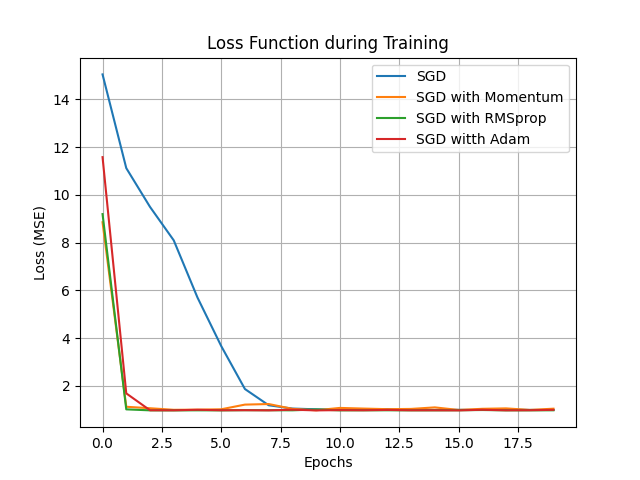

# Problemas de Regressão

Existem duas categorias principais de aprendizado supervisionado:

* Classificação
* Regressão

**Classificação**

A classificação lida com a previsão de variáveis pertencentes à categorias que representam classes ou rótulos discretos. Por exemplo, classificar e-mails como spam ou não spam, ou prever se um paciente tem alto risco de doença cardíaca. Os algoritmos de classificação aprendem a mapear os recursos de entrada para uma das classes predefinidas. Os exemplos que temos lidados até aqui pertencem a esta categoria. Em alguns casos, precisamos conhecer as probabilidades de uma varíavel pertencer à uma categoria ou não. Usa-se então a função *sigmoid*, ou *softmax* quando são várias categorias (ver o exemplo com a classificação de gênro segundo pesos e alturas).

**Regressão**

A regressão, por outro lado, lida com a previsão de variáveis-alvo contínuas, que representam valores numéricos. Por exemplo, prever o preço de uma casa com base em seu tamanho, localização e comodidades, ou prever as vendas de um produto. Os algoritmos de regressão aprendem a mapear os recursos de entrada para um valor numérico contínuo.

    Regressão Linear :A regressão linear é um tipo de algoritmo  supervisionado que aprende com conjuntos de dados rotulados e mapeia os pontos de dados com funções lineares otimizadas, que podem ser usadas para previsão em novos conjuntos de dados. Ela calcula a relação linear entre a variável dependente e uma ou mais características independentes, ajustando uma equação linear com dados observados. Ela prevê as variáveis de saída contínuas com base na variável de entrada independente.
    Por exemplo, se quisermos prever o preço de um imóvel, consideramos vários fatores, como idade do imóvel, distância da estrada principal, localização, área e número de cômodos. A regressão linear usa todos esses parâmetros para prever o preço do imóvel, pois considera uma relação linear entre todas essas características e o preço do imóvel.

    Regressão Polinomial: A regressão polinomial é uma ferramenta poderosa para suavização de dados que pode ajudá -lo a fazer previsões, identificar tendências e muito mais.Envolve ajustar uma equação polinomial a um conjunto de pontos de dados, que podem ser usados para fazer previsões ou analisar tendências. É usada quando a relação entre as variáveis não é linear e os pontos de dados seguem uma tendência curvilínea. Por exemplo, uma curva em forma de U, ou uma relação cúbica.

Exemplo: Neste exemplo a força calculada sobre o peso ligado à uma mola é calculada como $F=mg$ e para cada peso (o qual cresce em intervalos de 50 g) é medida a distensão da mola $\Delta x$. Os valores são inseridos em um algoritmo de regressão linear ( neste caso, uma calculadora HP prime) e o ajuste é realizado.  

<table>
    <tr>
      <td>
      <img src='.\Mola1.png'width=400>
      </td>
      <td>
      <img src='.\Mola2.png'width=400>
      </td>
      <td>
      <img src='.\Mola3.png'width=400>
      </td>
     </tr>
</table>

## Exemplos com Keras/Tensorflow

### a) Regressão Linear

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend

In [ ]:
np.random.seed(0)
num_points = 100
X1 = np.linspace(0,1, num_points)
y1 = 4 + 3 * X1 + np.random.randn(num_points)/3

fig = plt.figure(figsize=(5, 5))
plt.scatter(X1, y1)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.show()

### Uma Camada e Um Neurônio

In [ ]:
backend.clear_session()
np.random.seed(0)
random.seed(0)
tf.random.set_seed(0)
model1 = Sequential()
model1.add(Dense(1, activation='linear', input_shape=(1,)))
model1.compile(optimizer='adam', loss='mse', metrics=['mse'])
model1.summary()

In [ ]:
history1 = model1.fit(X1, y1, epochs=1000, verbose=0,
                      batch_size=X1.shape[0])

In [ ]:
X1_test = np.linspace(0,1, 1000)
yhat1 = model1.predict(X1_test)

fig = plt.figure(figsize=(5, 5))
plt.scatter(X1, y1, label="Train data")
plt.plot(X1_test, yhat1, color="red", label="Prediction")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(loc="best", fontsize=11)
plt.show()

### Rede com Múltiplas camadas

In [ ]:
backend.clear_session()
np.random.seed(15)
random.seed(15)
tf.random.set_seed(15)

input_layer = Input(shape=(1,))
x = Dense(50, activation='linear')(input_layer)
output_layer = Dense(1, activation='linear')(x)
model2 = Model(inputs=input_layer, outputs=output_layer)

model2.compile(optimizer='adam', loss='mse', metrics=['mse'])
model2.summary()

In [ ]:
history2 = model2.fit(X1, y1, epochs=500, verbose=0,
                      batch_size=X1.shape[0])

In [ ]:
X1_test = np.linspace(0,1, 1000)
yhat1 = model2.predict(X1_test)

fig = plt.figure(figsize=(5, 5))
plt.scatter(X1, y1, label="Train data", alpha=0.7)
plt.plot(X1_test, yhat1, color="red", label="Prediction")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(loc="best", fontsize=11)
plt.show()

### b) Recursão Quadrática (Não Linear)

In [ ]:
np.random.seed(0)
num_points = 100
X2 = np.linspace(0,1, num_points)
y2 = -(X2-0.5)**2 + 0.25

fig = plt.figure(figsize=(5, 5))
plt.scatter(X2, y2)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.show()

### Uma camada e um neurônio

In [ ]:
backend.clear_session()
np.random.seed(0)
random.seed(0)
tf.random.set_seed(0)

model3 = Sequential()
model3.add(Dense(1, activation='relu', input_shape=(1,)))
model3.compile(optimizer='adam', loss='mse', metrics=['mse'])

In [ ]:
history3 = model3.fit(X2, y2, epochs=500, verbose=0,
                      batch_size=X2.shape[0])

In [ ]:
X2_test = np.linspace(0,1, 1000)
yhat2 = model3.predict(X2_test)

fig = plt.figure(figsize=(5, 5))
plt.scatter(X2, y2, label="Train data")
plt.plot(X2_test, yhat2, color="red", label="Prediction")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(loc="best", fontsize=11)
plt.show()

### Rede com Múltiplas camadas

In [ ]:
backend.clear_session()
np.random.seed(15)
random.seed(15)
tf.random.set_seed(15)

input_layer = Input(shape=(1,))
x = Dense(100, activation='relu')(input_layer)
output_layer = Dense(1, activation='linear')(x)
model4 = Model(inputs=input_layer, outputs=output_layer)

model4.compile(optimizer='adam', loss='mse', metrics=['mse'])
model4.summary()

In [ ]:
history4 = model4.fit(X2, y2, epochs=1500, verbose=0,
                      batch_size=X2.shape[0])

In [ ]:
X2_test = np.linspace(0,1, 1000)
yhat2 = model4.predict(X2_test)

fig = plt.figure(figsize=(5, 5))
plt.scatter(X2, y2, label="Train data", alpha=0.7)
plt.plot(X2_test, yhat2, color="red", label="Prediction")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(loc="best", fontsize=11)
plt.show()

## Regressão Logística


A Regressão Logística é um dos algoritmos de aprendizado de máquina mais comuns. Ela pode ser usada para prever a probabilidade de ocorrência de um evento, como se um e-mail recebido é spam ou não, ou se um tumor é maligno ou não, com base em um determinado conjunto de dados rotulados.

Devido à sua simplicidade, a regressão logística é frequentemente usada como base para a avaliação de outros modelos mais complexos.
 O nome "Logística" vem da utilização da função *sigmoid* para converter a combinação linear de um conjunto de dados em probabilidades, e não apenas classificar os dados em categorias. O método é classificado como regressão pelo fato que sua saída é um valor contínuo entre 0 e 1, embora seja normalmente usado como um classificador binário, escolhendo um valor limite (geralmente 0,5) e classificando entradas com probabilidade maior que o limite como classe positiva, e aquelas abaixo do limite como classe negativa. Pelos motivos acima a função *sigmoid* é também conhecida como **Função Logística**.

 As funções *Sigmoid* e *SoftMax* atuam sobre uma variável $ -\infty \le x \le \infty$ transformando-as em um número $ 0 \le p(x) \le 1$ que representa a probabilidade de $x$ pertencer à uma certa classe ou categoria. 
 * Sigmoid: Usada para classificação binária, e seu resultado representa a probabilidade de $x$ pertencer a uma classe específica, enaquanto que a probabilidade de percencimento à uma segunda classe é dada por $1-p(x)$.
 * SoftMax : usada para problemas de múltiplas classes, e é uma extensão da função *Sigmoid*. A função é vetorizada, significando que a entrada  **x** é um vetor com o mesmo número de termos que as classes ou categorias do problema, a as sáidas são as probabilidades de cada elemento de **x** pertencer à uma dada categoria. 


* $P(y=k/X=x)$ é a probabilidade de $y$ pertencer à categoria k se $X$ tem o valor x. Então podemos escrever

  $$ X \in \mathbb{R} \rightarrow Sigmoid/SoftMax \rightarrow P(y=k/X=x) \in [0,1]$$

* Em estatística, probabilidade e odds (ou chances) são duas formas diferentes de expressar a chance de um evento ocorrer.

* A probabilidade $P(A)$, ou a probabilidade de um evento $A$ ocorrer é dada por:

  $$ P(A)=\frac{\text{Número de casos favoráveis}}{\text{Número total de casos possíveis}},$$ onde $P(A) \in [0,1] $. Como exemplos, a probabilidade de obter cara em um lance de moeda é $\frac{1}{2}=0,5$, ou seja, é um caso favorável em duas possibilidades,  enquanto a probabilidade de um lance de dado resultar no número 6 é $\frac{1}{6}$.

* As odds (chances)  são simplesmente a razão entre a probabilidade de um evento ocorrer e a probabilidade de ele não ocorrer, ou seja:

  $$ odds(A)=\frac{P(A)}{1-P(A)}$$

  onde se, por exemplo, $P(A)=1$, então $odds(A)=\infty$, e daí $odds(A) \in [0,\infty)$. Nos exemplos anteriores, se A é um lance de moeda resultando em cara, então $odds(A)=1$, e se A é o lance de um dado resultando no número 6, então $odds(A)=\frac{\frac{1}{6}}{1-\frac{1}{6}}=\frac{1}{5}$. Ainda, se dissermos que as chances de um determinado corredor chegar em primeiro em uma corrida são $\frac{3}{8}$, então isso significa que em 11 corridas o corredor vence 3 e perde 8.



**A regressão logística é uma extensão da regressão linear**. No problema de regressão linear os pesos $w_i$ são encontrados tal que 
$$z=w_0+w_1x_1+w_2 x_2+\textellipsis +w_mx_m\;\in\;(-\infty,\infty)$$
Por sua vez  a função logística ou *Sigmoid*  mapeia o intervalo $(-\infty,\infty)$ no intervalo $[0,1]$: Vamos escrever $z=logit(P(x))$, onde

$$ logit(P(x))=Ln\left(\frac{P(x)}{1-P(x)}\right)$$


Assim,
    $$z=Ln\left(\frac{P(x)}{1-P(x)}\right) \rightarrow e^z = \frac{P(x)}{1-P(x)},$$

onde como definido acima $z=\omega_0+\omega_1x_1 +\textellipsis + \omega_mx_m$ é a soma ponderada das entradas ao último neurônio. 

Resolvendo para $P(x)$ temos

$$P(x)(1+e^z)=e^z\rightarrow P(x)=\frac{e^z}{1+e^z}=\frac{1}{1+e^{-z}}.$$


Por outro lado, a função *Softmax* tem como entrada um vetor cuja dimensão é o número de categorias do problema de classificação,  ou seja, 
$$\bf{h}=\begin{bmatrix}h1\\h2\\\vdots\\h_k\end{bmatrix}$$
onde $h_i$ é a saída do i-ésimo neurônio da camada anterior. Como anteriormente, $h_i \in (-\infty,\infty)$ e precisamos de um vetor onde cada elemento é uma probabilidade tal que $P_i \in [0,1]$. Além disso, as probabilidades tem que ter sua soma igual a unidade, ou seja, o vetor de saída deve ser uma distribuição de probabilidades sobres as classes possíveis. Estendendo o procedimento adotado na função Logística ao vetor $\bf(h)$, teremos
$$ \bf{h}=\begin{bmatrix}logit(P(y=\text{classe 1}|x)\\logit(P(y=\text{classe 2}|x)\\\vdots\\logit(P(y=\text{classe k}|x))\end{bmatrix}$$

Entretanto, a função *Sigmoid* não pode ser aplicada aqui porque são obtidas apenas probabilidades isoladas patra cada elemento de $\bf{h}$, não uma distribuição de probabilidade sobre todas as classes. Como exemplo, suponha-se que o vetor $\bf{h}$ seja formado pelos valores $\{ 3.,1.75,-2.,0.5\}$. A aplicação da função *Sigmoid* resultará nos valores $\{0.95,0.85,0.12,0.62\}$, cuja soma é aproximadamente 2.55, ou seja, não é uma distribuição de probabilidades. Para converter  $\bf{h}$ em uma correta distribuição de probabilidade, podemos aplicar a função exponencial para cada termo do vetor de forma que $e^{h_i} = e^{ln(odds(P(h_i)))}= odds(P(h_i))\in [0,\infty)$. Esta operação resulta em  uma estimativa das probabilidades, mas para termos uma distribuição, ou seja, para que a soma de todos os elementos seja igual a 1, normalizamos (dividimos)  cada $e^{h_i}$ pela somatória de todos os termos, ou seja, 

$$SoftMax=\frac{e^{h_i}}{\sum_j e^{h_j} }$$

Repetindo agora o exemplo anterior, obtemos os valores $\{0.725,0.21,0.005,0.06\}$ cuja soma é igual a 1. Temos então uma distribuição de probabilidades.

* **Função MSE x *logloss***

  A regressão logística se caracteriza pelo uso de funções *Sigmoid* para comprimir a saída na faixa entre zero e um, e assim resultar em uma função de probabilidade, e no uso da função *logloss* no cálculo do erro ao invés do mínimo erro quadrático (MSE). A função *Logloss* é 

 $$f=-yln(p)-(1-y)ln(1-p)$$

e a função custo é

$$ J(w)=-\frac{1}{n}\sum_{i=1}^{n}(y(ln(\hat{y_i})+(1-y)ln(1-\hat{y_i})) $$

 Agora, vamos ver como a função logarítmica acima funciona nos dois casos de uso da regressão logística, ou seja, quando o valor de saída real é 1 ou 0.
Como dito acima, em geral  a saída do modelo de regressão logística é a probabilidade de a amostra de entrada ser positiva (indicada por 1). Se um modelo de regressão logística for treinado para classificar um e-mail como spam e não spam, onde o e-mail sendo spam (=positivo) é indicado como 1 e não spam (=negativo) como 0, então a saída do modelo *p* é a probabilidade de o e-mail ser spam (=positivo). Se quisermos a probabilidade de o e-mail não ser spam (=negativo), ela pode ser representada como *1-p*.

 Se, por exemplo, o valor verdadeiro é $y=1$ e duas saídas são $p_1=0,4$ e $p_2=0,6$ é esperado que na avaliação $p_1$ sofra uma penalidade maior que $p_2$, pois $p_2 > 0,5$. Substituindo na expressão da função *logloss* temos:

  $ -ln(0,4)=0,92$ enquanto que $-ln(0,6)=0,51$, ou seja , a penalidade sobre a probabilidade mais baixa ("mais errada") é maior. 

  Caso contrário, se o valor verdadeiro é $y=0$, com as mesmas saídas $p_1$ e $p_2$, então, $-ln(1-0,4)=-ln(0,6)=0,51$, enquanto $-ln(1-0,6)=-ln(0,4)=0,92$, ou seja, $p_2$ é mais penalizada. Além disso, podemos perceber que em caso de disparate total na resposta, ou seja, $y=1$ e $p=0$, $J(w)=-yln(0)\rightarrow \infty$ enquanto que o a função custo MSE tem sua resposta limitada em 1. 

 Outro fator importante na escolha de uma função custo adequada é a convexidade da mesma em função dos pesos $w_i$. A convexidade de uma função depende da sua derivada segunda, ou seja, para uma função convexa a derivada segunda deve ser não negativa em todo domínio da função. Isto pode ser mostrado como segue:

 sabemos que se uma função $f(x)$ é convexa, então para três pontos quaisquer $x_1\;,x_c\;\text{e}\;x_2,\;x1<x_c<x_2$, podemos escrever

 $$f(x_c)\le\frac{f(x_1)+f(x_2)}{2}.$$

 No intervalo entre $x_c$ e $x_1$ existe um ponto $x_{c1}$ tal que (teorema do valor intermediário):

 $$ f(x_c)-f(x_1)=f'(x_{c1})(x_c-x_1).$$

 O mesmo vale para o intervalo entre os pontos $x_c$ e $x_2$, ou seja, existe um ponto $x_{c2}$ entre eles tal que

 $$ f(x_2)-f(x_c)=f'(x_{c2})(x_2-x_c).$$

 Subtraindo estas duas expressões temos, 

 $$2f(x_c)-f(x_1)-f(x_2)=f'(x_{c1})(x_c-x_1)-f'(c_{c2})(x_2-x_c),$$

 e usando novamente o teorema do valor intermediário para a derivada segunda em um ponto $x_{c3}$ entre $x_{c1}$ e $x_{c2}$ resulta em

 $$f'(x_{c2})-f'(x_{c1})=f^{"}(x_{c3})(x_{c2}-x_{c1}).$$

 Façamos agora a suposição que $f^{"}(x_{c3})\ge 0$. Então $f'(x_{c2})-f'(x_{c1}) \ge 0$, implicando $2f(c)-f(x_1)-f(x_2) \le 0$. Portanto, $f(x_c)\le\frac{f(x_1)+f(x_2)}{2}$.
 
 No caso da função *Logloss* atuando no neurônio de saída, a sua derivada em função de $\hat{y}$ é inicialmente calculada como (considerando  o número de características *n=1*)

 $$\frac{\partial J(\hat{y})}{\partial\hat{y}}=-\frac{y}{\hat{y}}+\frac{1-y}{a-\hat{y}}=\frac{-y(1-\hat{y})+\hat{y}(1-y)}{\hat{y}(1-\hat{y})}=\frac{\hat{y}-y}{\hat{y}(1-\hat{y})}$$

 onde o denominador do último termo é, como já foi visto, a derivada das função *Sigmoid* com respeito à $x$, e portanto a derivada com respeito à *w* é 
 
 $$\frac{\partial }{\partial w}\left(\frac{1}{1+e^{-wx}}\right)=x\frac{e^{-wx}}{\left(1+e^{-wx}\right)^2}=x\hat{y}(1-\hat{y}).$$

 Usando as duas últimas derivadas parciais para obter $\frac{\partial J(w)}{\partial w}$ , temos, 

 $$\frac{\partial J(w)}{\partial w}=\frac{\partial J(\hat{y})}{\partial \hat{y}}\frac{\partial \hat{y}(w)}{\partial w}=\frac{\hat{y}-y}{\hat{y}(1-\hat{y})} x\hat{y}(1-\hat{y})=x(\hat{y}-y)=\frac{x}{1+e^{-wx}}-xy,$$ 

e para *n >1* características,

$$\frac{\partial {J(w)}}{\partial w_j}=\frac{1}{n}\sum_{i=1}^{n} [(p_i-y_i) x_{ij}].$$
 A derivada segunda da função *Logloss* em função dos pesos *w* é, calculada diretamente das expressões anteriores
 $$ \frac{\partial^2J}{\partial w^2}=\frac{\partial x(\hat{y}-y)}{\partial w}=x\frac{\partial \hat{y}}{\partial w}=x^2\hat{y}(1-\hat{y})=\frac{x^2e^{-wx}}{(1+e^{-wx})^2}.$$

Portanto $ \frac{\partial^2J}{\partial w^2} \ge 0$, pois $\infty \ge \; e^{-wx}\;\ge 0$ para $x \in (-\infty,\infty)$, e assim a função *Logloss* associada com a função de ativação *sigmoid* é convexa.

Por outro lado, a função custo MSE é $J(w)=(y-\hat{y})^2$, e assim,
$$\frac{\partial J}{\partial w}=\frac{\partial  }{\partial \hat{y}}\frac{\partial \hat{y}}{\partial w}=-2(y-\hat{y})\hat{y}(1-\hat{y})x=-2(y\hat{y}-y\hat{y}^2-\hat{y}^2+\hat{y}^3)x=g(w)$$
a derivada segunda pode finalmente ser calculada como
$$\frac{\partial^2 J}{\partial w^2}=\frac{\partial g}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial w}=-2(y-2y\hat{y}-2\hat{y}+3\hat{y}^2)\hat{y}(1-\hat{y})x^2,$$

$$ \frac{d^2f}{dw^2}=-2(3\hat{y}^2-2\hat{y}(y+1)+y)\hat{y}(1-\hat{y})x^2.$$

 $x^2\ge0$ e $0\le\hat{y}(1-\hat{y})\le\frac{1}{4}$ (O máximo ocorre quando $y_p=\frac{1}{2}$), portanto a convexidade da função MSE dependerá do primeiro termo entre parênteses. Note que em um problema de classificação, $y=1$ ou $y=0$. Daí, quando $y=0$, temos que $-[3\hat{y}^2-2\hat{y}(y+1)+y]=-[3\hat{y}^2-2\hat{y}]=-3\hat{y}(\hat{y}-\frac{2}{3})< 0 $ quando $\hat{y}\;\in\;(\frac{2}{3},1]$. Por outro lado, quando $y=1$, temos $-[3\hat{y}^2-2\hat{y}(y+1)+y]=-[3\hat{y}^2-4\hat{y}+1]=-[3(\hat{y}-\frac{1}{3})(\hat{y}-1)] < 0$ quando $\hat{y}\;\in\;[0,\frac{1}{3})$. Portanto, podemos concluir que a função MSE não será convexa em algumas faixas de valores de $\hat{y}$, podendo dificultar a convergência no algorítmo do Método dos gradientes descendentes.

Outra dificuldade com o MSE é o possível erro de cancelamento e arredondamento na operação $(y-\hat{y})^2$ para valores próximos das duas variáveis.

Para verifcação desta análise usaremos o conjunto de dados Íris (licença BSD). O conjunto de dados original contém 150 amostras de flores Íris que pertencem a uma de três espécies, Íris setosa, Íris versicolor ou Íris virginica. Para classificação binária apenas os dois primeiros tipos (setosa e versicolor) serão usados, e também apenas as duas primeiras características de cada flor (largura e comprimento da sépala). Para a contrução do modelo será usado apenas um perceptron, no qual a otimização dos pesos será realizada pelo método dos gradientes descendentes. É necessário portanto que as duas categorias sejam linearmente separáveis. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, :2]  # somente as duas primeiras características (comprimento e largura)
y = iris.target       # 0=setosa,1=versivolor e 2=virginica

# seleciona flores setosa e versicolor
X = X[(y == 0) | (y == 1)] # apenas dados cuja classe seja setosa ou versicolor
y = y[(y == 0) | (y == 1)] # apenas os rótulos dessas duas classes

def plot_data(X, y):
    # Plota os pontos de dados
    plt.scatter(X[y==0, 0], X[y==0, 1],c='red',label='setosa')
    plt.scatter(X[y==1, 0], X[y==1, 1],c='blue',label='versicolor')
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.legend() 

plot_data(X,y)

Como pode ser visto na figura acima o conjunto de dados é linearmente separável, portanto a regressão logística deve ser capaz de encontrar o limite entre as duas classes.

In [ ]:
# Adiciona uma coluna para as *bias*
n = X.shape[0] 
X_with_bias = np.hstack((np.ones((n, 1)), X))

# separa os dados em conjunto de treino e conjunto de teste

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_with_bias, y, random_state=0)

* Implementa o Modelo:

In [ ]:
def sigmoid(z):
    # z pode ser um escalar ou um vetor
    z = np.array(z)
    return 1 / (1 + np.exp(-z))

def cost_function(X, y, w):
    # Custo
    p = sigmoid(X @ w)    
    J = -(1/n) * (y @ np.log(p) + (1-y) @ np.log(1-p)) 

    # Gradiente    
    grad = (1/n) * X.T @ (p - y)  
    return J, grad


In [ ]:
def model_sgd(X, y, alpha=0.01, max_iter=5000, tol=0.0001):
     """  
    X, y: dados de treino        
    alpha: taxa de aprendizado
    max_iter: máximo numero de iterações sobre o conjunto de dados
    tol: critério de parada
    """
     w = np.random.rand(X.shape[1])
     cost, grad = cost_function(X, y, w)
     
     for i in range(max_iter):
        w = w - alpha * grad
        new_cost, grad = cost_function(X, y, w)        
        if np.abs(new_cost-cost) < tol:
            print(f'Convergiu após {i} interações')
            return w, new_cost
        cost = new_cost

     print('Maximo número of interações atingido')
     return w, cost

* Otimização do modelo

In [ ]:
w_ot, cost = model_sgd(X_train, y_train)

print('w_otim:', w_ot)
print('Custo com  w_otim:', cost)

* Linha de Fronteira

A linha de fronteira é definida pelos pontos para os quais a previsão do nosso modelo é exatamente 0,5, ou seja,

$$p=sigmoid(\bf{w}^T\bf{x})=0,5\rightarrow \frac{1}{1+e^{-w^Tx}}=0,5\rightarrow 1+e^{-w^Tx}=2 \rightarrow e^{-wTx}=1$$
e então $\bf{w^Tx}=0$. Daí,$ \bf{w^Tx}$=$w_0+w_1 x_1+w_2 x_2=0$, ou ainda

$$ x_2=-\frac{1}{w_2}\left(w_1x_1+w_0\right)$$  

In [ ]:
def plot_decision_boundary(X, y, w):
   
    plot_data(X, y)

    line_x = np.array(plt.gca().get_xlim()) # retorna os limites no eixo x; line_x=[x_min,x_max]
    line_y = -1 / w[2] * (w[1] * line_x + w[0]) 
    plt.plot(line_x, line_y, c='k', ls='--')

In [ ]:
plot_decision_boundary(X, y, w_ot)

* Predições com o Modelo
  
 A função  predict_prob() calcula as previsões do modelo com base no cálculo da função sigmoide de $x^Tw$.

In [ ]:
def predict_prob(X, w):
    """ retorna a probabilidades que as amostras em X petençam a classe versicolor 
    """
    p = sigmoid(X @ w)
    return p

In [ ]:
predict_prob([[1, 6, 2]], w_ot) # amostra localizada em (6,2) 

Esta amostra tem 89,5% de chance de ser uma flor versicolor.

In [ ]:
predict_prob([[1, 5.5, 3]], w_ot) #amostra localizada em (5.5,3)

Desta vez a probabilidade é bem menor (apenas 56,4%), pois esta amostra está próxima da fronteira entre as classes.

In [ ]:
predict_prob([[1, 5.5, 4]], w_ot) #amostra localizada em (5.5,4)

Probabilidade de 22,7% de ser uma versicolor, ou 77,3 % de ser uma setosa.


* Acurácia do Modelo
* 
A função predict() abaixo determina diretamente a classe a qual percence a amostra, retornando 1 para versicolor, ou 0 em caso contrário. A acurácia do modelo pode ser assim determinada com a função evaluate_model(), onde  é calculada como:

  $$ \text{Acurácia}=\frac{\text{ Previsões corretas}}{\text{Total de previsões}}$$

In [ ]:
def predict(X, w):
    """ predição da classe a qual pertence a amostra"""
    p = sigmoid(X @ w)
    y_pred = (p >= 0.5).astype(int)
    return y_pred
    
def evaluate_model(X, y, w):
    y_pred = predict(X, w)
    accuracy = np.mean(y == y_pred)
    return accuracy

In [ ]:
train_accuracy = evaluate_model(X_train, y_train, w_ot)
print(f'Train accuracy: {train_accuracy * 100:.3f}%')

In [ ]:
test_accuracy = evaluate_model(X_test, y_test, w_ot)
print(f'Test accuracy: {test_accuracy * 100:.3f}%')

* Teste com maior número de épocas e menor tolerância

In [ ]:
w_ot, cost = model_sgd(X_train, y_train,max_iter=3000000, tol=0.000000001)

print('w_otim:', w_ot)
print('Custo com  w_otim:', cost)

In [ ]:
plot_decision_boundary(X, y, w_ot)

In [ ]:
predict_prob([[1, 6, 2]], w_ot)

In [ ]:
predict_prob([[1, 5.5, 3]], w_ot)

In [ ]:
predict_prob([[1, 5.5, 3.8]], w_ot)

In [ ]:
train_accuracy = evaluate_model(X_train, y_train, w_ot)
print(f'Train accuracy: {train_accuracy * 100:.3f}%')

In [ ]:
test_accuracy = evaluate_model(X_test, y_test, w_ot)
print(f'Test accuracy: {test_accuracy * 100:.3f}%')

# Redes Neurais Convolucionais

São basicamente redes neurais que utilizam camadas convolucionais baseadas na operação matemática da convolução. As camadas convolucionais consistem em um conjunto de filtros, que podem ser consideradas como matrizes bidimensionais de números.

Podemos usar uma imagem de entrada e um filtro   para produzir uma imagem de saída convoluindo o filtro com a imagem de entrada. A operação de convolução entre duas funções $f(t)$ e $g(t)$ é a integral 
$$f(t)*g(t)= \int_{-\infty}^{\infty} f(t-\tau)g(\tau)d\tau$$

Isso consiste em:

* Sobrepor o filtro sobre a imagem em algum local.
* Realizar a multiplicação elemento a elemento entre os valores no filtro e seus valores correspondentes na imagem.
* Somar todos os produtos elemento a elemento. Essa soma é o valor de saída para o pixel de destino na imagem de saída.
Repetir para todos os locais.

Considere uma imagem consistindo de 16 *pixels* em uma estrutura matricial 4x4, onde cada número da matriz corresponde à intensidade do *pixel*, a ser convoluída  com um filtro representado por uma matriz de dimenõses 3 X 3. Durante o processo o filtro irá se sobrepor aos elementos na sub-matriz 3x3 no canto superior esquerdo, gerando o primeiro *pixel* na imagem convoluída. Depois o filtro desloca-se um nível para direita, e um novo *pixel* é gerado. O processo é repetido depois do filtro ser deslocado 1 nível avaixo sobre a imagem original, resultanto em mais dois *pixels*. Este processo resultando em uma matriz 2 X 2é mostrado na figura abaixo:

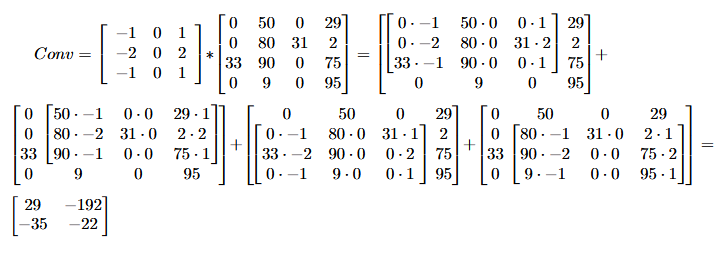

*Stride*  é a distância que o filtro percorre em cada passo ao longo de uma direção. No exemplo acima usamos *stride*=1. 

O filtro mostrado no exemplo é conhecido como filtro de Sobel, e é apropriado para identificar linhas verticais em uma imagem. A transposição de um filtro de Sobel resulta em um filtro de Sobel horizontal.

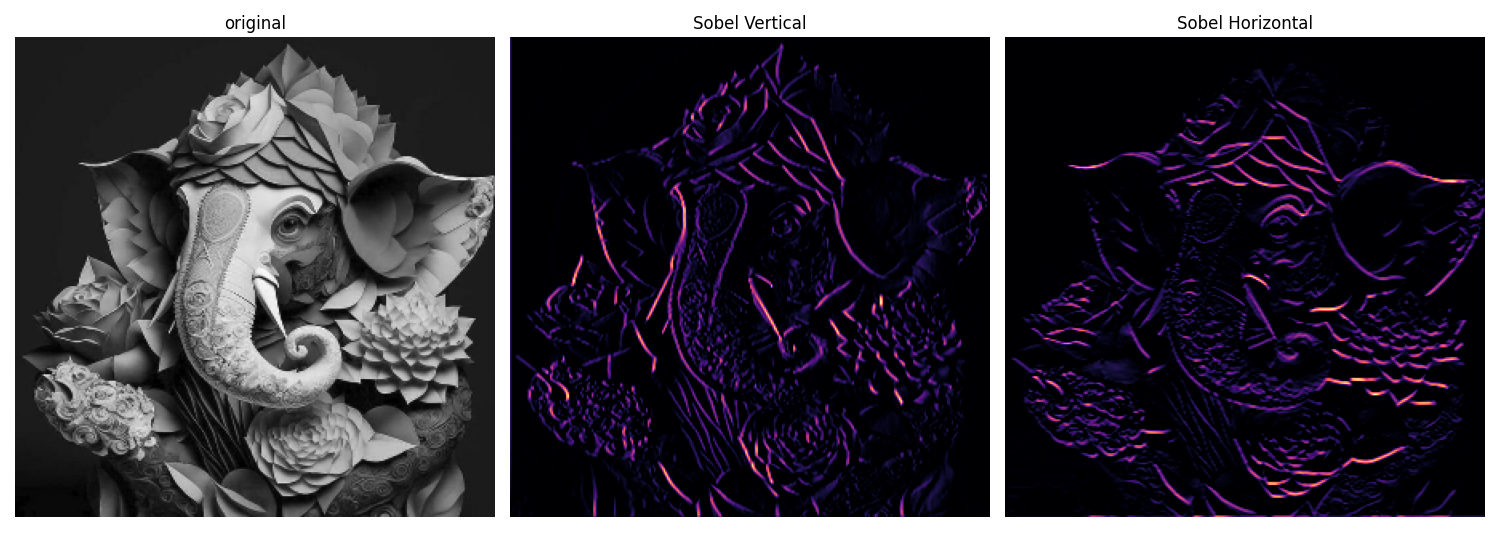

## *Padding*

Como vimos, convoluindo uma imagem 4x4 com um filtro 3x3 resulta em uma imagem de saída de dimensão 2x2. Entretanto, usando *padding* a imagem de saída pode ter a mesma dimensão que a imagem original. Para isto, zeros são adicionados em torno da imagem de forma que o filtro pode ser sobreposto nela em mais lugares. Esta técnica é chamada de "**same Padding**". Caso *padding* não seja usado, algumas vezes será chamado de "**Valid Padding**". Veja na figura abaixo que com a técnica *same-Padding* e *stride*=1 teremos 4 convoluções por linha, e 4 por coluna, resultando em uma matriz 4 X 4. 

$$Conv=\begin{bmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{bmatrix} * \begin{bmatrix} 0&0&0&0&0&0\\0&0&50&0&29&0\\0&0&80&31&2&0\\0&33&90&0&75&0\\0&0&9&0&95&0\\0&0&0&0&0&0&\end{bmatrix}=\begin{bmatrix} 180&31&-120&-31\\300&29&-192&-62\\269&-35&-22&-31\\108&-33&157&0\end{bmatrix}$$

## Camadas Convolutivas

As redes convolucionais  incluem camadas de convolução que usam um conjunto de filtros para transformar imagens de entrada em imagens de saída. O parâmetro principal de uma camada de convolução é o número de filtros que ela possui.

Se uma rede usa uma pequena camada de convolução com 8 filtros na camada inicial,  então se, por exemplo, a imagem de entrada tiver resolução de 28x28 *pixels*, eles serão transformados em um volume de saída de 26x26x8 (se *valid padding* está sendo usado), como ilustrado na figura abaixo:

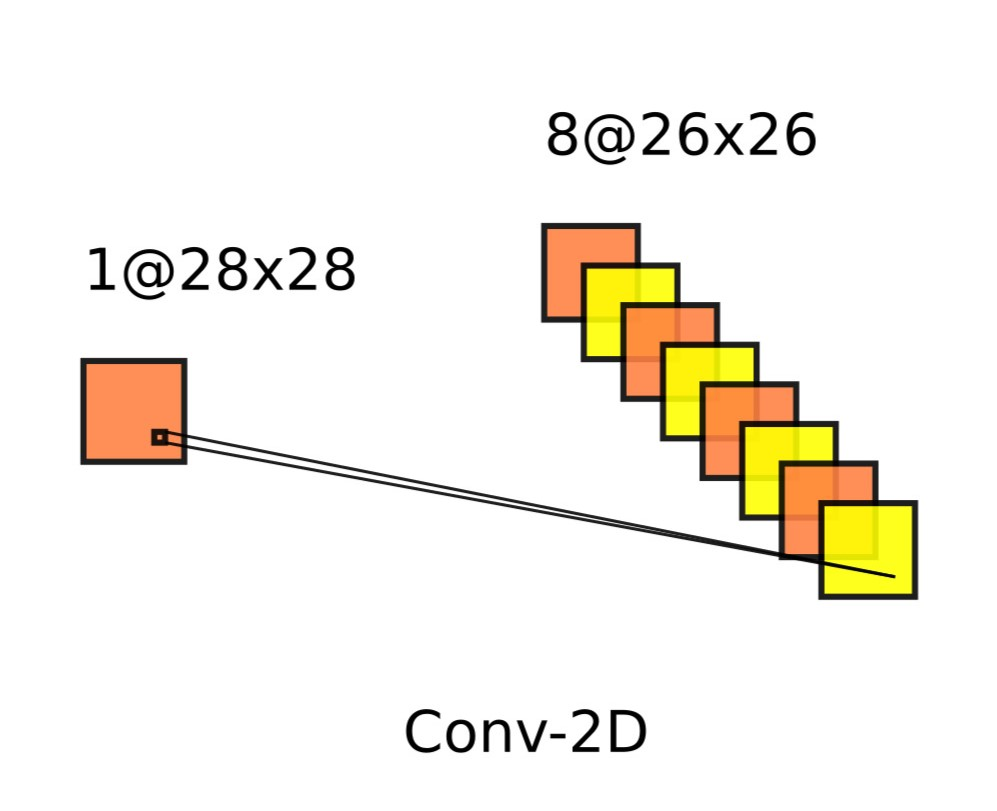

Cada um dos 8 filtros na camada de convolução produz uma saída de 26x26, os quais empilhados formam um volume de 26x26x8. Considerando que os 8 filtros tem dimensão3×3, então o número de pesos será igual à 8 X 9 = 72 ! Isto é muito menos do que se fosse uma camada completamente conectada. 

In [1]:
# ==============================
# Exemplo de Função de convolução
# ==============================

def convolve2d(image, kernel, padding=0, stride=1):
    # Na convolução o filtro pode ser invertido antes de atravessar a imagem, como acontece na integral de convolução. 
    #kernel = np.flipud(np.fliplr(kernel))  # Rotação 180°
    x_k, y_k = kernel.shape
    x_i, y_i = image.shape

    if padding > 0:
        image_padded = np.pad(image, pad_width=padding, mode='constant')
    else:
        image_padded = image
    #determina a dimensão da imagem de saída com base nos valores de padding e stride
    x_o = ((x_i + 2 * padding - x_k) // stride) + 1
    y_o = ((y_i + 2 * padding - y_k) // stride) + 1
    output = np.zeros((x_o, y_o))

    for i in range(0, x_o):
        for j in range(0, y_o):
            region = image_padded[i*stride:i*stride+x_k, j*stride:j*stride+y_k]
            output[i, j] = np.sum(region * kernel)

    return output

In [2]:
import numpy as np

# Imagem de entrada (4x4)
image = np.array([
    [0, 50, 0, 29],
    [0,80, 31, 2],
    [33, 90, 0, 75],
    [0, 9, 0, 95]
])

# Filtro (3x3)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Passo 1: Convolução
conv_out = convolve2d(image, kernel, padding=1)
print("\nSaída da Convolução:")
print(conv_out)


Saída da Convolução:
[[ 180.   31. -120.  -31.]
 [ 300.   29. -192.  -62.]
 [ 269.  -35.  -22.  -31.]
 [ 108.  -33.  157.    0.]]


## *Pooling*

Pixels vizinhos em imagens tendem a ter valores semelhantes, portanto, as camadas de convolução normalmente também produzem valores semelhantes para pixels vizinhos nas saídas. Como resultado, grande parte da informação contida na saída de uma camada de convolução é redundante. Por exemplo, se usarmos um filtro de detecção de bordas e encontrarmos uma borda forte em um determinado local, é provável que também encontremos bordas relativamente fortes em locais deslocados de um pixel em relação ao original. No entanto, todas essas bordas se referem a mesma , nâo constituem informação adicional.

Uma camada de *pooling* é um tipo de camada de rede que reduz a resolução e agrega informações dispersas. Sua função principal é remover informações redundantes, reduzindo assim a quantidade de computação e memória necessárias, o que torna o modelo mais robusto à pequenas variações na entrada. Assim as camadas de *pooling* reduzem o tamanho da entrada fornecida agrupando os seus valores. Este agrupamento geralmente é feito por uma operação simples como máximo, mínimo ou média. Quando usamos o máximo, o nome utilizado para esta técnica é *max Pooling*.

Como funciona o *Max Pooling*:

1) Varredura: O *Max Pooling* move uma pequena janela (geralmente 2x2 ou 3x3) sobre o mapa de características de entrada.

2) Seleção: Em cada janela, o *Max Pooling* seleciona o valor máximo. É como escolher a informação mais importante naquela área.

3) Redução de resolução: Após selecionar os valores máximos de todas essas janelas, o *Max Pooling* reduz o tamanho do mapa de características. A imagem fica menor, mas os detalhes essenciais permanecem intactos.

Assim, para realizar o *max pooling*, percorre-se a imagem de entrada em blocos 2x2 (se o tamanho do bloco = 2) e coloca-se o valor máximo na imagem de saída no pixel correspondente.
O *pooling* divide a largura e a altura da entrada pelo tamanho do bloco. Para a rede 28x28, colocaremos uma camada de *max pooling* com um tamanho de bloco  2 logo após a camada de convolução inicial. A camada de *pooling* transformará uma entrada de 26x26x8 em uma saída de 13x13x8:

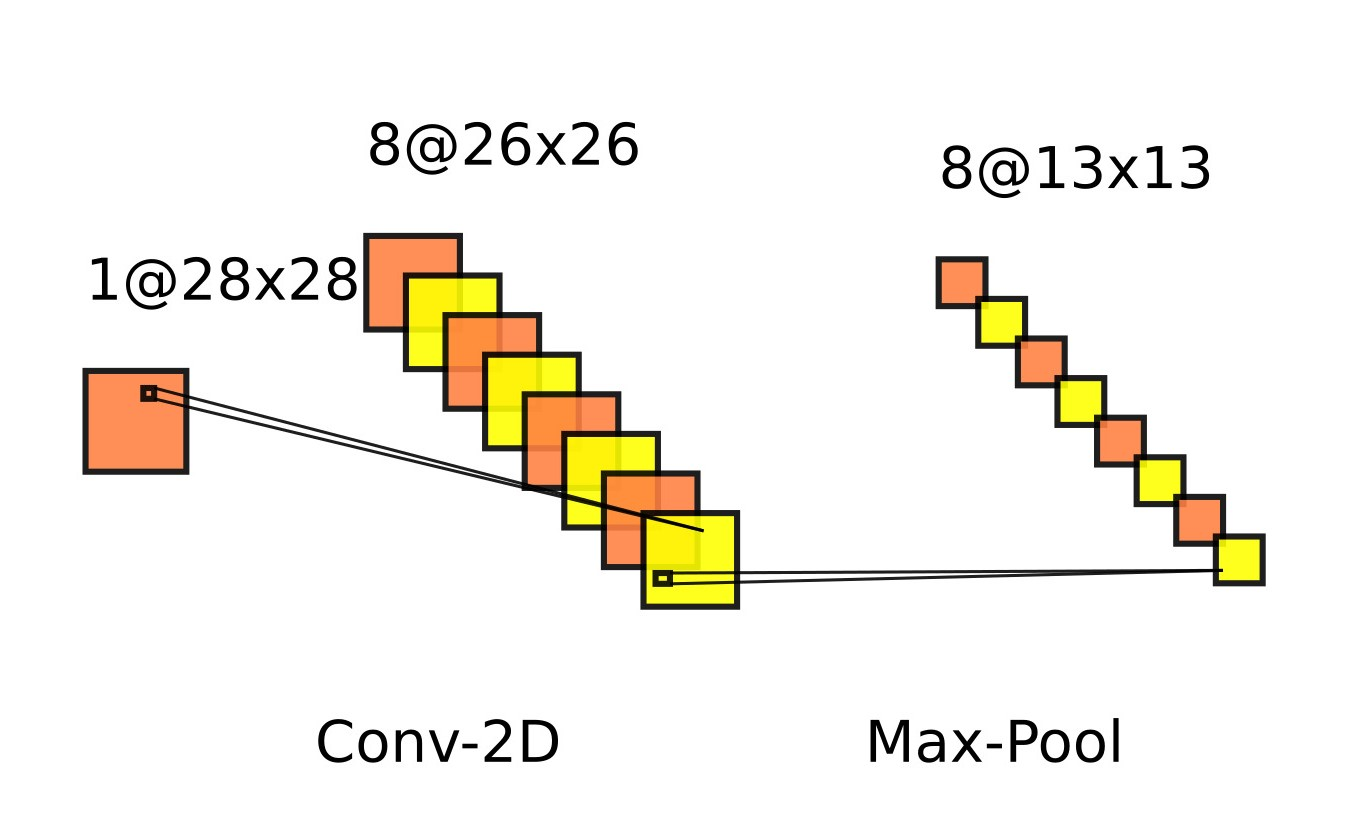

In [ ]:
# =======================================
# Max Pooling
# =======================================
def max_pooling(feature_map, size=2, stride=1):
    x_f, y_f = feature_map.shape
    x_o = ((x_f - size) // stride) + 1
    y_o = ((y_f - size) // stride) + 1
    pooled = np.zeros((x_o, y_o))

    for i in range(x_o):
        for j in range(y_o):
            region = feature_map[i*stride:i*stride+size, j*stride:j*stride+size]
            pooled[i, j] = np.max(region)

    return pooled

In [ ]:
pool_out = max_pooling(conv_out, size=2, stride=1)
print("\nSaída do Max Pooling:")
print(pool_out)

**Exemplo de aplicação em reconhecimento de imagens**: a base de dados do MNIST (*Modified National Institute of Standards and Technology database*) é um grande banco de dados de dígitos manuscritos, comumente usado para treinar vários sistemas de processamento de imagens. É o equivalente ao "Olá, Mundo!" (*Hello World*) da visão computacional, onde para uma dada imagem o problema consiste em classificá-la como um dígito específico corretamente.

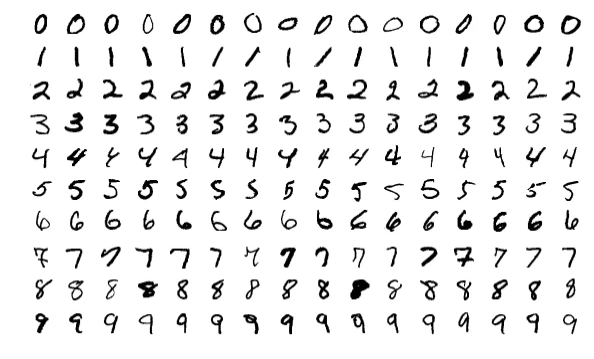

Cada imagem no conjunto de dados MNIST tem 28x28 *pixels* e contém um dígito centralizado em tons de cinza. Os 10 dígitos correspondem a 10 categorias, por tanto uma camada *Softmax* será utilizada nesta aplicação como uma camada de saída com 10 elementos, na qual a função *Softmax* é a função custo (*Lost*). Após a aplicação da transformação *Softmax*, o dígito representado pelo nó com maior probabilidade será a saída da rede.

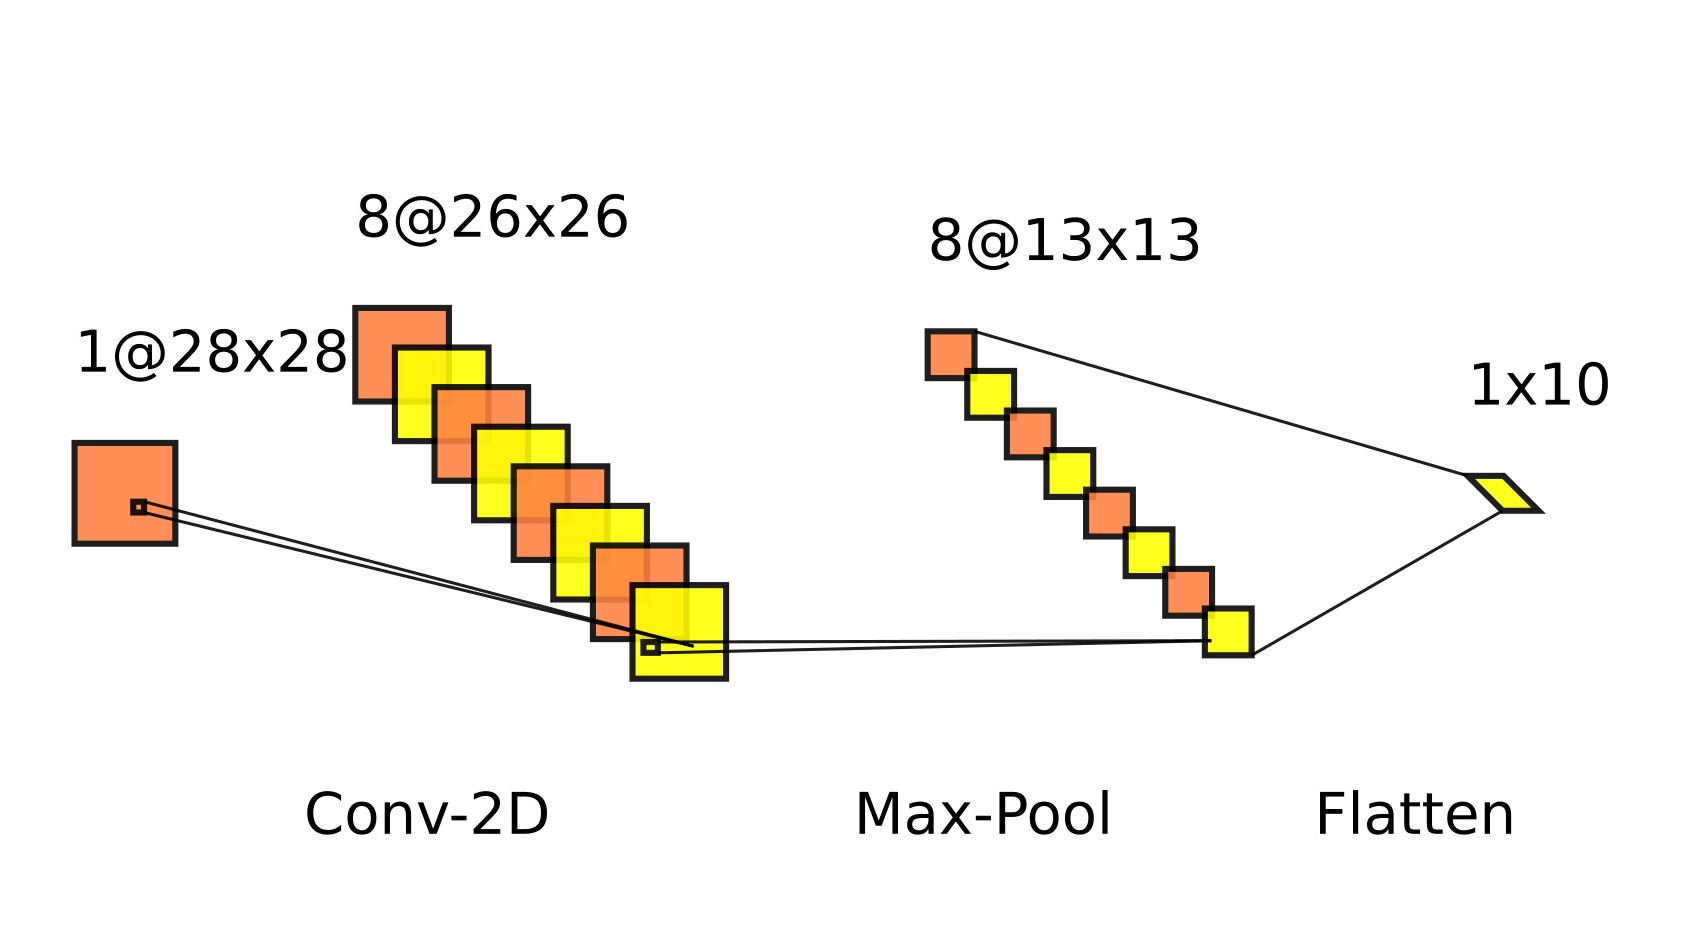

Antes de continuarmos, precisamos estudar algun detalhes sobre a função *Softmax*: 

O objetivo da rede é a classificação de imagens em categorias. A camada final é uma camada padrão para classificação multiclasse totalmente conectada usando a função *Softmax* como ativação. Cada nó na camada será conectado a todas as entradas (saídas da camada de *pooling*). Com a aplicação da função *Softmax*, o dígito representado pelo nó com probabilidade mais alta será a saída da rede. 

$$\hat{y}_c=\frac{e^{z_c}}{\sum_i e^{z_i}}=\frac{e^{z_c}}{S}=e^{z_c}S^{-1}$$

  onde $S=\sum_i e^{z_i}$.

Seja $k\ne c$. A derivada da saída em relação a $z_k$ é

  $$\frac{\partial \hat{y}_c}{\partial z_k} =\frac{\partial \hat{y}_c}{\partial S}\frac{\partial S}{\partial z_k}=-e^{z_c}S^{-2}\frac{\partial S}{\partial z_k}=-\frac{e^{z_c}e^{z_k}}{S^2}$$

  Agora, se $k=c$, a derivada é

  $$\frac{\partial \hat{y}_c}{\partial z_c}=\frac{\partial\left(e^{z_c}S^{-1}\right)}{\partial z_c}=\frac{e^{z_c}}{S}+e^{z_c}\frac{\partial S^{-1}}{\partial z_c}=\frac{e^{z_c}}{S}-\frac{e^{z_c}e^{z_c}}{S^2}=\frac{e^{z_c}(S-e^{z_c})}{S^2}.$$

  portanto,
  
  $$\frac{\partial \hat{y}}{\partial z}=\begin{cases}-\frac{e^{z_c}e^{z_k}}{S^2},& k \ne c \\
\frac{e^{z_c}(S-e^{h_c})}{S^2},& k=c \end{cases}$$

  

## Treinamento

O treinamento de uma rede neural normalmente consiste em duas fases:

* Uma fase *feedforward*, onde a entrada é passada completamente pela rede.
* Uma fase de *backpropagation*, onde os gradientes são retropropagados e os pesos são atualizados.

Durante a fase de avanço, cada camada armazenará em cache quaisquer dados (como entradas, valores intermediários, etc.) necessários para a fase de retropropagação. Isso significa que qualquer fase de retropropagação deve ser precedida por uma fase de avanço correspondente. Na saída da camada de *pooling* os dados são "achatados" na forma de um *array* unidimensional (em *numpy* usa-se a função *flatten()*), e então encaminhados para o cálculo das probabilidades pela camada *Softmax*. 


Durante a fase de retropropagação, na camada de saída é calculado um gradiente da perda em relação às suas saídas ($\frac{\partial L}{\partial \hat{y}_c}​$) e  o gradiente de perda em relação às suas entradas ($\frac{\partial L}{\partial h}​​$). A função de perdas é a função denominada como *Cross-Entropy Loss*, a qual considera o o grau de certeza uma dada previsão é simplesmente definida como
$$L=-\ln(p_c)$$

onde *c* é a classe correta (no nosso caso, o dígito correto), $p_c=\hat{y}_c$ é a probabilidade prevista para a classe *c* e $\ln$ é o logaritmo natural. Note que para $\hat{y}_c=1$, $L=0$, enquanto que para um valor como $\hat{y}_c=0.4$, $L=0.9$. Portanto, quanto menor o valor da perda melhor a probabilidade de ser a saída correta. 

* Feedforward

    out=conv.feedforward(image)

    out=pool.feedforward(out)

    out=softmax.feedforward(out)

* Cálculo dos gradientes

    ......
  
    ......

* backpropagation
  
    gradient=softmax.backprop(gradient)
  
    gradient=pool.backprop(gradient)
  
    gradient=conv.backprop(gradient)

No início do treino, cada imagem é testada com seu verdadeiro *label*, se a base de dados é **MNIST**, o verdadeiro dígito. Isso significa que apenas um dos 10 elementos do *array* corresponderá ao ao dígito $y_c$. Portanto o gradiente inicial é

$$\frac{\partial L}{\partial \hat{y}_i}=\begin{cases}0,& i \ne c \\
-\frac{1}{p_i},& i=c \end{cases}$$

ou seja, o vetor de gradientes será um vetor nulo com $-\frac{1}{p_c}$ ná posição do *label* correto, semelhante à um vetor *one-hot*. 

Na camada de saída, para cada neurônio $z=w*h_{in}+b$, portanto, os gradientes são:

  $$\frac{\partial z}{\partial w}=h_{in};$$
  $$\frac{\partial z}{\partial b}=1;$$
  $$\frac{\partial z}{\partial h_{in}}=\omega,$$

  e finalmente,

  $$\frac{\partial L}{\partial \omega}=\frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial z}\frac{\partial z}{\partial \omega}$$
  $$\frac{\partial L}{\partial b}=\frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial z}\frac{\partial z}{\partial b}$$
  $$\frac{\partial L}{\partial h_{in}}=\frac{\partial L}{\partial\hat{y} }\frac{\partial \hat{y}}{\partial z}\frac{\partial z}{\partial h_{in}}$$

  * *Pooling*

Uma camada *Max Pooling*  não pode ser treinada porque na verdade não tem nenhum peso, mas ainda é necessário implementar um método *backprop()* para que ela calcule gradientes.
Durante o *feedforward*, a camada *pooling* recebe um volume de entrada e reduz pela metade suas dimensões de largura e altura, escolhendo os valores máximos ( para *maxpooling*) em blocos 2x2. Na retropropagação a largura e a altura do gradiente de perda são dobradas, atribuindo cada valor de gradiente ao local onde o valor máximo original estava em seu bloco 2x2 correspondente. Todos os outros valores são mantidos nulos. O motivo é que um pixel de entrada que não é o valor máximo em seu bloco 2x2 não tem efeito na perda, porque alterar ligeiramente esse valor não altera a saída.

* Camada *Conv*

Já calculamos $\frac{\partial L}{\partial \hat{y}}​$ para a camada de convolução, então precisamos apenas de $\frac{\partial \hat{y}}{\partial filter}$. ​Assim, precisamos saber como a alteração do peso de um filtro afeta a saída da camada de convolução. Vamos considerar um exemplo no qual uma imagem 3x3 convoluída por um filtro 3x3 contendo inicialmente apenas zeros. 

Se o peso no centro do filtro for alterado para 1, o resultado é o aumento do resultado da  convolução  pelo valor do pixel na imagem original. O mesmo se dará pelo aumento dos pesos em qualquer outro local no filtro. 

Assim, podemos escrever

$$\hat{y}(i,j)=imagem*filtro=\sum_{k=0}^3 \sum_{l=0} ^3 imagem(i+k,j+l)\times filtro(k,l)\rightarrow \frac{\partial \hat{y}(i,j)}{\partial filtro(k,l)}=imagem(i+k,j+l)$$ 
 e portanto

 $$\frac{\partial L}{\partial filtro(k,l)}=\sum_i\sum_j\frac{\partial L}{{\partial \hat{y}(i,j)}} \times \frac{\partial \hat{y} (i,j)}{\partial filtro(k,l)}$$



In [ ]:
class Conv3x3:
  # ...

  def backprop(self, d_L_d_out, learn_rate):
    
    d_L_d_filters = np.zeros(self.filters.shape)

    for im_region, i, j in self.iterate_regions(self.last_input):
      for f in range(self.num_filters):
        d_L_d_filters[f] += d_L_d_out[i, j, f] * im_region

    # Update filters
    self.filters -= learn_rate * d_L_d_filters
    return None

## Implementação com Keras

Uma rede CNN é implementada abaixo com a biblioteca Keras, com a base de dados MNIST. Cada imagem tem pixels com valores inteiros de 0 a 255 (8 bits), portanto os dados de treino e teste serão normalizados de forma a terem seus valores no intervalo [0,1]. Além disso, reduzindo 0,5 do intervalo resulta em um novo intervalo centrado em zero, [-0.5,0.5]. Centrar os dados facilita o aprendizado com gradientes mais estáveis e funciona melhor com as funções de ativação. Faremos um primeiro teste com a configuração padrão de uma camada convolucional 2D, uma camada *MaxPooling* e uma camada densa de 10 elementos/categorias. Também são usados 8 filtros 3 X 3. 

In [21]:
import numpy as np
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()


# Normalização das imagens.
train_images = (train_images / 255) - 0.5 # normalização e centragem
test_images = (test_images / 255) - 0.5   ## normalização e centragem

# Acrescenta uma dimensâo às imagens.
train_images = np.expand_dims(train_images, axis=3)
test_images = np.expand_dims(test_images, axis=3)

num_filters = 8
filter_size = 3
pool_size = 2
input_shape=(28, 28, 1)

# Build the model.
model = Sequential([
  keras.Input(shape=input_shape),
  Conv2D(num_filters, filter_size, activation = 'relu',use_bias=False),
  MaxPooling2D(pool_size=pool_size),
  Flatten(),
  Dense(10, activation='softmax'),
])

model.summary()

# Compila o modelo.
model.compile(
  'adam',
  loss='categorical_crossentropy',
  metrics=['accuracy'],
)

# treina o modelo.
model.fit(
  train_images,
  to_categorical(train_labels),
  epochs=15,
  validation_data=(test_images, to_categorical(test_labels)),
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 26, 26, 8)           │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 13, 13, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 1352)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │          13,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,602 (53.13 KB)

 Trainable params: 13,602 (53.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8584 - loss: 0.5791 - val_accuracy: 0.9673 - val_loss: 0.1167
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9697 - loss: 0.1087 - val_accuracy: 0.9739 - val_loss: 0.0855
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9775 - loss: 0.0767 - val_accuracy: 0.9764 - val_loss: 0.0783
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9804 - loss: 0.0658 - val_accuracy: 0.9772 - val_loss: 0.0695
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9836 - loss: 0.0553 - val_accuracy: 0.9799 - val_loss: 0.0614
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9836 - loss: 0.0526 - val_accuracy: 0.9799 - val_loss: 0.0632
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9851 - loss: 0.0487 - val_accuracy: 0.9802 - val_loss: 0.0625
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9868 - loss: 0.0443 - 

In [22]:
score = model.evaluate(test_images, to_categorical(test_labels), verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Test loss: 0.06682071089744568
Test accuracy: 0.9812999963760376


Para cada época, o treinamento fornece os seguintes dados de saída:

 Accuracy (acurácia): Acompanha a proporção de previsões corretas que o modelo faz nos dados de treinamento. Inicialmente, a acurácia do modelo começa em torno de  85% e aumenta gradualmente à medida que aprende a classificar melhor as imagens.

 Loss (perda): Mede o quão bem as previsões do modelo se alinham com os rótulos reais. Cada época deve mostrar uma diminuição na perda, indicando que o modelo  está aprendendo.
 
 val_accuracy: Semelhante à acurácia, mas para o conjunto de validação, indica o desempenho do modelo em  dados diferentes do usado no treinamento.

 val_loss: A perda no conjunto de validação, usada para monitorar a generalização para dados diferentes do usado no treinamento.

Para um total de 13602 parâmetros a rede atingiu uma acurácia de apr0ximadamente 98%. O aumento do número de épocas não muda consideravelmente este resultado.  Portanto, podemos testar uma segunda configuração com uma camada de convolução de 32 filtros na sequência da camada de entrada, seguida pela camada *Maxpooling*, por uma nova camada de convolução, desta vez com 64 filtros, *maxPooling e finalmente a camada densa de 10 categorias. 

In [23]:
from keras.layers import Dropout
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        Conv2D(32, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dropout(0.5),
        Dense(10, activation="softmax"),
    ]
)

model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(train_images, to_categorical(train_labels), batch_size=batch_size, epochs=epochs, validation_split=0.1,verbose=1)

score = model.evaluate(test_images, to_categorical(test_labels), verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7553 - loss: 0.8037 - val_accuracy: 0.9800 - val_loss: 0.0782
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9638 - loss: 0.1189 - val_accuracy: 0.9842 - val_loss: 0.0563
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9756 - loss: 0.0838 - val_accuracy: 0.9858 - val_loss: 0.0510
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9776 - loss: 0.0729 - val_accuracy: 0.9888 - val_loss: 0.0418
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9807 - loss: 0.0655 - val_accuracy: 0.9880 - val_loss: 0.0417
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9812 - loss: 0.0614 - val_accuracy: 0.9902 - val_loss: 0.0383
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9842 - loss: 0.0493 - val_accuracy: 0.9898 - val_loss: 0.0337
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9851 - loss: 0.0463 - val_accu

Desta vez, com 34826 parâmetros atingiu-se aproximadamente 99% de acurácia nos dados de validação e treinamento. 

### Referências
[1] https://victorzhou.com/blog/intro-to-cnns-part-1/

[2] https://www.geeksforgeeks.org/building-a-convolutional-neural-network-using-pytorch/

[3] https://keras.io/examples/vision/mnist_convnet/

[4]https://medium.com/@techwithjulles/convolutional-neural-networks-cnns-for-time-series-data-experimenting-with-different-e2dcd9fc76ba

[5] Serkan Kiranyaz,Onur Avci, Osama Abdeljaber, Turker Ince, Moncef Gabbouj, Daniel J. Inman: 1D convolutional neural networks and applications: A survey , Mechanical Systems and Signal Processing, 2021.

[6] https://keras.io/api/layers/convolution_layers/convolution2d/

[6] Matheus Bona, Aplicação de Redes Neurais Artificiais na Localização de Faltas em Linhas de Transmissão, Dissertação de Mestrado, Furb, setembro, 2021.
